#Введение
В работе будут построены и обучены следующие модели:
1. **GARCH**. Для прогнозирования волатильности криптовалют
2. **LSTM/GRU**. Рекуррентные сети, хорошо подхохдящие для прогнозирования временных рядов
3. **TCN**. Временная сверточная сеть, также используемая для прогнозирования временных рядов
4. **TimesFM**. Большая базовая модель от Google, обученная для работы с временными рядами
5. **Chronos**. Базовая модель от Amazon, так же созданная для временных рядов
6. **Гибридные модели**. Это сочетание 2х и более моделей, например, ARIMA + LSTM

Прогнозироваться будут 5 самых капитализированных криптовалют на момент февраля 2026, а именно: Bitcoin, Ethereum, TetherUSDt, XRP (Riple), BNB (BinanceCoin)

#Получение данных

Для скачивания данных о курсе монет используется библиотека ccxt, которая имеет в себе унифицированный API, позволяющий работать с сотнями бирж

Получим датасеты для каждой из перечисленных монет c интервалами разной длины. 3 месяца, год и 5 лет. Прогнозирование будет происходить на дни вперёд, поэтому необходимо узнать на каком интервале будет наибольшая точность.

In [2]:
import ccxt
import pandas as pd
import numpy as np
import time
import requests
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import random
random.seed(1)

In [3]:
exchange = ccxt.kucoin()

symbols = {
    "BTC/USDT": "btc",
    "ETH/USDT": "eth",
    "XRP/USDT": "xrp",
    "LTC/USDT": "ltc"
}

timeframes = {
    "5_years": 365 * 5
}

TIMEFRAME = "1d"
LIMIT = 1000

def onchain_fun(asset, d):
    metrics = "AdrActCnt, TxCnt"
    base_url = "https://community-api.coinmetrics.io/v4/timeseries/asset-metrics"
    df = pd.DataFrame(columns=["date", "active_addresses", "tx_count"])

    params = {
        "assets": asset,
        "metrics": metrics,
        "start_time": (datetime.utcnow() - timedelta(days=d)).strftime("%Y-%m-%d"),
        "frequency": "1d",
        "pretty": "true"
    }

    current_url = base_url

    while True:

        r = requests.get(current_url, params=params, timeout=30)
        r.raise_for_status()
        response_json = r.json()

        if "data" in response_json and response_json["data"]:
            temp_df = pd.DataFrame(response_json["data"])
            temp_df["date"] = pd.to_datetime(temp_df["time"]).dt.date
            temp_df = temp_df.rename(columns={
                "AdrActCnt": "active_addresses",
                "TxCnt": "tx_count"
            })

            df = pd.concat([df, temp_df[["date", "active_addresses", "tx_count"]]], ignore_index=True)

        current_url = response_json.get('next_page_url')

        if not current_url:
            break

        params = {}

    df["active_addresses"] = pd.to_numeric(df["active_addresses"])
    df["tx_count"] = pd.to_numeric(df["tx_count"])
    df = df.sort_values("date").reset_index(drop=True)
    return df

def fetch_ohlcv_range(symbol, days):
    since = exchange.parse8601(
        (datetime.utcnow() - timedelta(days=days))
        .strftime("%Y-%m-%dT%H:%M:%S")
    )

    all_candles = []

    while True:
        candles = exchange.fetch_ohlcv(
            symbol,
            timeframe=TIMEFRAME,
            since=since,
            limit=LIMIT
        )

        if not candles:
            break

        all_candles.extend(candles)
        since = candles[-1][0] + 1

        if len(candles) < LIMIT:
            break

        time.sleep(exchange.rateLimit / 1000)

    df = pd.DataFrame(
        all_candles,
        columns=["timestamp","open", "high", "low", "close", "volume"]
    )

    df["date"] = pd.to_datetime(df["timestamp"], unit="ms").dt.date
    return df[["date", "close", "volume"]]

for symbol, asset in symbols.items():
    for period, days in timeframes.items():

        price_df = fetch_ohlcv_range(symbol, days)
        block_df = onchain_fun(asset, days)

        merged_df = pd.merge(price_df, block_df, on='date', how='inner')

        filename = f"{symbol.replace('/', '_')}_{period}.csv"
        merged_df.to_csv(filename, index=False)


C:\r2\ipykernel_14152\3921492198.py:62: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  (datetime.utcnow() - timedelta(days=days))
C:\r2\ipykernel_14152\3921492198.py:25: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "start_time": (datetime.utcnow() - timedelta(days=d)).strftime("%Y-%m-%d"),
C:\r2\ipykernel_14152\3921492198.py:62: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  (datetime.utcnow() - timedelta(days=days))
C:\r2\ipykernel_14152\3921492198.py:25: DeprecationWarning: datetime.datetime.utcnow() is deprecated an

In [4]:
btc_5years = pd.read_csv('BTC_USDT_5_years.csv')
btc_5years.set_index('date', inplace = True)

eth_5years = pd.read_csv('ETH_USDT_5_years.csv')
eth_5years.set_index('date', inplace = True)

ltc_5years = pd.read_csv('LTC_USDT_5_years.csv')
ltc_5years.set_index('date', inplace = True)

xrp_5years = pd.read_csv('XRP_USDT_5_years.csv')
xrp_5years.set_index('date', inplace = True)

#Визуализация

Рассмотрим графики рядов

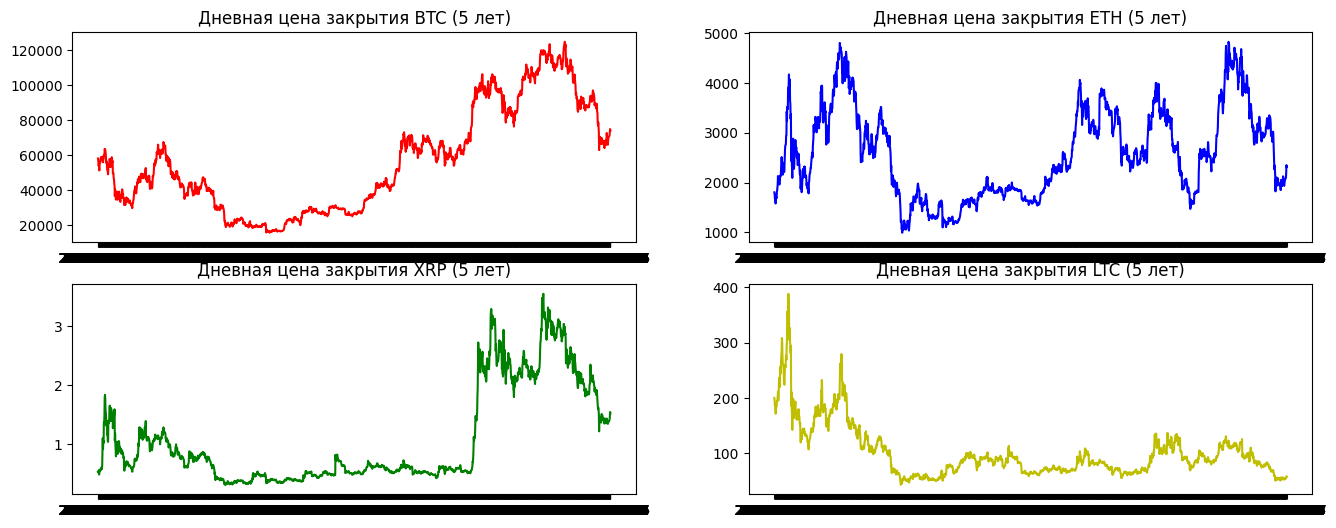

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(16, 6))

axs[0, 0].plot(btc_5years['close'], 'r')
axs[0, 0].set_title('Дневная цена закрытия BTC (5 лет)')
axs[0, 1].plot(eth_5years['close'], 'b')
axs[0, 1].set_title('Дневная цена закрытия ETH (5 лет)')
axs[1, 0].plot(xrp_5years['close'], 'g')
axs[1, 0].set_title('Дневная цена закрытия XRP (5 лет)')
axs[1, 1].plot(ltc_5years['close'], 'y')
axs[1, 1].set_title('Дневная цена закрытия LTC (5 лет)')

plt.show()

#GARCH

 GARCH является статистической моделью, для неё необходимо привести ряды к стационарности. Смотря на графики выше, можно понять, что ряды нестационарны, поэтому приведём ряды к стационарности путём взятия разностей и проверим стационарность тестом Дики-фулера.

In [29]:
from statsmodels.tsa.stattools import adfuller

#добавим признак логаримф доходности, для обучения garch модели
#это позволит достичь стационарности

pool = {
    "BTC": btc_5years,
    "ETH": eth_5years,
    "XRP": xrp_5years,
    "LTC": ltc_5years
}

for name, df in pool.items():
  df['log_return'] = np.log(df['close'] / df['close'].shift(1))
  df.dropna(inplace = True)

#тест дики-фуллера
for name, p in pool.items():
  res = adfuller(p['log_return'])
  print(f"P-value {name} = {res[1]} ", end = '')
  if res[1] < 0.05:
    print("- ряд стационарен")
  else: print("- ряд не стационарен")

P-value BTC = 4.091181992261017e-12 - ряд стационарен
P-value ETH = 0.0 - ряд стационарен
P-value XRP = 1.663064343223906e-22 - ряд стационарен
P-value LTC = 3.829149649770671e-25 - ряд стационарен


In [ ]:
from arch import arch_model

pool_1year = {
    "BTC": btc_5years,
    "ETH": eth_5years,
    "XRP": xrp_5years,
    "LTC": ltc_5years
}

def garch(df, p, q, dist='t'):

  # split = int(0.92 * len(df)) #в каждом датасете одинаковое количество наблюдений

  #формируем обучающие и тестовые выбоки
  train = df[:-180]
  test = df[-180:]
  model = arch_model(train['log_return'], vol='GARCH', p=p, o = 1, q=q, power = 2, dist=dist, rescale = False)
  # model = arch_model(train['log_return'], vol='EGARCH', p=p, q=q, dist=dist, rescale = False)
  results = model.fit(disp='off')

  forecast = results.forecast(start=len(train) - 1, horizon=len(test), method = 'simulation', reindex=False)

  train_vol = results.conditional_volatility
  train_realized = train['log_return'].values

  var_forecast = forecast.variance.values[-1, :]
  vol_forecast = np.sqrt(var_forecast)

  realized_vol = test['log_return'].values

  mape = (np.abs((realized_vol - vol_forecast**2))).sum() * 100 / len(realized_vol)
  # Получаем AIC и BIC из результатов модели
  aic = results.aic
  bic = results.bic

  return {
    'model': results,
    'forecast': forecast,
    'vol_forecast': vol_forecast,
    'mape': mape,
    'aic': aic,
    'bic': bic,
    'params': {'p': p, 'q': q}
  }

for name, df in pool_1year.items():
  for i in range (1, 5+1):
    for j in range (1, 5+1):
      result = garch(df, p=i, q=j)
      a = result['mape']
      aic = result['aic']
      bic = result['bic']
      print(f'{name} MAPE = {a:.2f}%, AIC = {aic:.2f}, BIC = {bic:.2f}, p = {i}, q = {j}')

BTC MAPE = 1.78%, AIC = -7186.71, BIC = -7154.29, p = 1, q = 1
BTC MAPE = 1.78%, AIC = -7214.90, BIC = -7177.07, p = 1, q = 2
BTC MAPE = 1.78%, AIC = -7200.09, BIC = -7156.85, p = 1, q = 3
BTC MAPE = 1.78%, AIC = -7197.62, BIC = -7148.99, p = 1, q = 4
BTC MAPE = 1.78%, AIC = -7195.34, BIC = -7141.30, p = 1, q = 5
BTC MAPE = 1.78%, AIC = -7184.01, BIC = -7146.18, p = 2, q = 1
BTC MAPE = 1.78%, AIC = -7193.01, BIC = -7149.78, p = 2, q = 2
BTC MAPE = 1.78%, AIC = -7195.78, BIC = -7147.14, p = 2, q = 3
BTC MAPE = 1.78%, AIC = -7193.08, BIC = -7139.04, p = 2, q = 4
BTC MAPE = 1.78%, AIC = -7197.20, BIC = -7137.75, p = 2, q = 5
BTC MAPE = 1.78%, AIC = -7183.01, BIC = -7139.78, p = 3, q = 1
BTC MAPE = 1.78%, AIC = -7188.71, BIC = -7140.07, p = 3, q = 2
BTC MAPE = 1.78%, AIC = -7189.80, BIC = -7135.75, p = 3, q = 3
BTC MAPE = 1.78%, AIC = -7187.42, BIC = -7127.98, p = 3, q = 4
BTC MAPE = 1.78%, AIC = -7187.46, BIC = -7122.61, p = 3, q = 5
BTC MAPE = 1.78%, AIC = -7184.34, BIC = -7135.70, p = 4

C:\r2\ipykernel_17160\1095422180.py:20: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  results = model.fit(disp='off')


XRP MAPE = 2.81%, AIC = -5473.43, BIC = -5419.39, p = 1, q = 5


C:\r2\ipykernel_17160\1095422180.py:20: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  results = model.fit(disp='off')


XRP MAPE = 4082012302.87%, AIC = 114578.53, BIC = 114616.36, p = 2, q = 1
XRP MAPE = 445230787089581120.00%, AIC = 189575.52, BIC = 189618.76, p = 2, q = 2
XRP MAPE = 2.87%, AIC = -6061.31, BIC = -6012.67, p = 2, q = 3
XRP MAPE = 22.71%, AIC = 404414.95, BIC = 404469.00, p = 2, q = 4


...

LTC MAPE = 2.74%, AIC = -5971.04, BIC = -5922.40, p = 3, q = 2
LTC MAPE = 20.58%, AIC = 11642.04, BIC = 11696.08, p = 3, q = 3
LTC MAPE = 2.72%, AIC = -5984.11, BIC = -5924.66, p = 3, q = 4
LTC MAPE = 7.64%, AIC = -4103.42, BIC = -4038.57, p = 3, q = 5
LTC MAPE = 2.72%, AIC = -5987.00, BIC = -5938.36, p = 4, q = 1
LTC MAPE = 440556586.28%, AIC = 76964.17, BIC = 77018.22, p = 4, q = 2


C:\r2\ipykernel_17160\1095422180.py:20: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  results = model.fit(disp='off')


LTC MAPE = 2.72%, AIC = -5984.11, BIC = -5924.66, p = 4, q = 3
LTC MAPE = 3.69%, AIC = -4296.37, BIC = -4231.52, p = 4, q = 4
LTC MAPE = 4.31%, AIC = -4749.57, BIC = -4679.31, p = 4, q = 5
LTC MAPE = 2379385.57%, AIC = 5353803.47, BIC = 5353857.51, p = 5, q = 1
LTC MAPE = 2832.03%, AIC = 408073.48, BIC = 408132.92, p = 5, q = 2


C:\r2\ipykernel_17160\1095422180.py:20: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  results = model.fit(disp='off')
C:\r2\ipykernel_17160\1095422180.py:20: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  results = model.fit(disp='off')


LTC MAPE = 2.69%, AIC = -5799.50, BIC = -5734.65, p = 5, q = 3
LTC MAPE = 3375538.88%, AIC = 38551.65, BIC = 38621.90, p = 5, q = 4
LTC MAPE = 3.66%, AIC = -4746.58, BIC = -4670.92, p = 5, q = 5


In [14]:
import warnings
warnings.filterwarnings('ignore')

Модели обучались на 4.5 летнем интервале и совершили прогноз волатильности на полгода вперед, лучшие метрики MAPE и параметры для каждой модели на тестовой выборке составили:
* BTC: GARCH MAPE = 1.7%, p = 1, q = 2
* ETH: GARCH MAPE = 2.67%, p = 1, q = 2
* XRP: GJR-GARCH MAPE = 2.79%, p = 2, q = 3, o = 1, power = 2
* LTC: GJR-GARCH MAPE = 2.67%, p = 1, q = 1, o = 1, power = 2

Дополнительно рассмотрим качество прогнозов на месяц вперед моделей, обученных на 1 летнем периоде:
* BTC: EGARCH MAPE = 2.69%, p = 1, q = 1
* ETH: EGARCH MAPE = 3.88%, p = 1, q = 4
* XRP: EGARCH MAPE = 3.74%, p = 1, q = 2
* LTC: EGARCH MAPE = 2.6%, p = 2, q = 1

Как видно, качество прогнозов упало, поэтому оптимальными моделями будем считать те, что обучены на периоде в 4.5 года

#LSTM

LSTM - рекуррентная нейронная сеть. Используем все имеющиеся признаки для прогнозов на месяц и полгода вперёд
Для подборки гиперпараметров модели используем библиотеку Optuna, а для построения самой сети библиотеку Keras

In [ ]:
#Установка и импорт библиотек
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

from keras.models import Sequential
from keras.layers import Input
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.layers import LSTM, GRU
import tensorflow as tf
from keras.callbacks import EarlyStopping

from xgboost import XGBRegressor

from tcn import TCN

In [ ]:
def split_norm(df, steps):
  train = df[:-steps]
  test = df[-steps:]

  scaler = MinMaxScaler()

  train = scaler.fit_transform(train.values)
  test = scaler.transform(test.values)

  return train, test, scaler

def make_sequences(train, lookback, steps):
  X_train = []
  y_train = []

  for i in range(lookback + 1, len(train) - steps + 1):
      X_train.append(train[i - lookback:i, :])
      y_train.append(train[i:i + steps, 0])

  return np.array(X_train), np.array(y_train)

def lstm(X_train, y_train, steps, n_features, b_size, e):
  tf.keras.backend.clear_session()

  model = Sequential()
  model.add(Input((X_train.shape[1], n_features)))
  model.add(LSTM(64, return_sequences = True))
  model.add(Dropout(0.1))
  model.add(LSTM(64, return_sequences = False))
  model.add(Dropout(0.7))
  
  # model.add(LSTM(128, return_sequences = True))
  # model.add(Dropout(0.1))
  # model.add(LSTM(32, return_sequences = True))
  # model.add(Dropout(0.7))
  # model.add(LSTM(16, return_sequences = False))
  # model.add(Dropout(0.8))
  model.add(Dense(steps))

  model.compile(
      optimizer = 'adam',
      loss = 'mean_squared_error',
      metrics = ['mae']
  )

  early_stopping = EarlyStopping(
      monitor = 'val_loss',
      patience = 5,
      restore_best_weights = True
  )

  history = model.fit(
      X_train, y_train,
      validation_split = 0.1, 
      batch_size = b_size,
      epochs = e,
      shuffle = False,
      callbacks = [early_stopping]

  )

  plt.plot(history.history["loss"], label="Loss на обучающей выборке")
  plt.plot(history.history["val_loss"], label="Loss на валидационной выборке")
  plt.xlabel("Номер эпохи")
  plt.ylabel("Функция потерь")
  plt.legend()

  return model

def make_predict(model, train, test, lookback, steps, scaler):
  last_window = train[-lookback:]
  X_pred = np.array([last_window])  # (1, lookback, n_features)

  pred_scaled = model.predict(X_pred, verbose=0)[0]  # (steps,)

  # обратное масштабирование
  dummy = np.zeros((steps, scaler.n_features_in_))
  dummy[:, 0] = pred_scaled
  pred = scaler.inverse_transform(dummy)[:, 0]

  # настоящие значения test
  dummy_true = np.zeros((steps, scaler.n_features_in_))
  dummy_true[:, 0] = test[:steps, 0]
  true = scaler.inverse_transform(dummy_true)[:, 0]

  return true, pred

def predict_train(model, train, lookback, scaler):
  # формируем последовательности для всего train
  X_train_full = np.array([train[i - lookback:i] for i in range(lookback, len(train))])
  pred_scaled = model.predict(X_train_full, verbose=0)[:, 0]  # только close
  dummy = np.zeros((len(pred_scaled), scaler.n_features_in_))
  dummy[:, 0] = pred_scaled
  model_train = scaler.inverse_transform(dummy)[:, 0]
  return model_train

def model_creation(coin, steps, lookback, n_features, batch_size, epochs):
  train, test, scaler = split_norm(coin, steps)
  X_train, y_train = make_sequences(train, lookback, steps)

  model = lstm(X_train, y_train, steps=steps, n_features=n_features, b_size=batch_size, e=epochs)

  # прогнозы
  true_test, pred_test = make_predict(model, train, test, lookback, steps, scaler)
  model_train = predict_train(model, train, lookback, scaler)

  # метрика
  mape = mean_absolute_percentage_error(true_test, pred_test)
  mae = mean_absolute_error(true_test, pred_test)
  print(f'MAPE = {mape:.4f}')
  print(f'MAE = {mae:.4f}')

  plt.figure(figsize=(12,4))

  # # фактический close train
  plt.plot(coin['close'].iloc[:len(train)], label='Train True', color='blue')

  # прогноз train
  plt.plot(pd.Series(model_train, index=range(lookback, len(train))), label='Train Pred', color='orange')

  # фактический close test
  plt.plot(coin['close'].iloc[len(train):len(train)+len(test)], label='Test True', color='green')

  # прогноз test
  plt.plot(pd.Series(pred_test, index=range(len(train), len(train)+steps)), label='Test Pred', color='red')

  plt.legend()
  plt.grid(False)
  plt.show()

  return model


Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0718 - mae: 0.2106 - val_loss: 0.0210 - val_mae: 0.1163
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0537 - mae: 0.1686 - val_loss: 0.0073 - val_mae: 0.0676
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0377 - mae: 0.1395 - val_loss: 0.0102 - val_mae: 0.0803
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0330 - mae: 0.1264 - val_loss: 0.0053 - val_mae: 0.0535
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0264 - mae: 0.1136 - val_loss: 0.0067 - val_mae: 0.0605
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0207 - mae: 0.1006 - val_loss: 0.0056 - val_mae: 0.0584
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0163 - mae: 0.0871 - val_loss: 0.0070 - val_mae: 0.0712
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0136 - mae: 0.0790 - val_loss: 0.0104 - val_mae: 0.0902
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.012

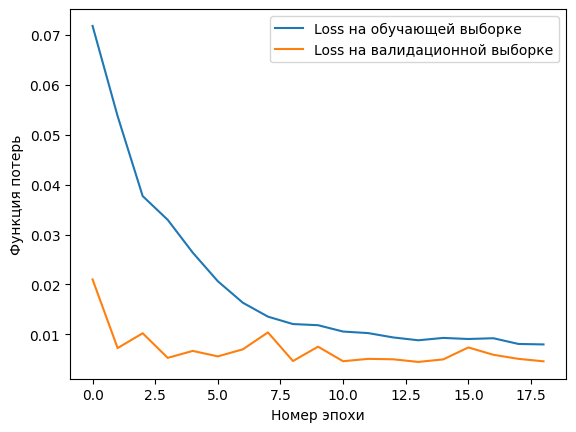

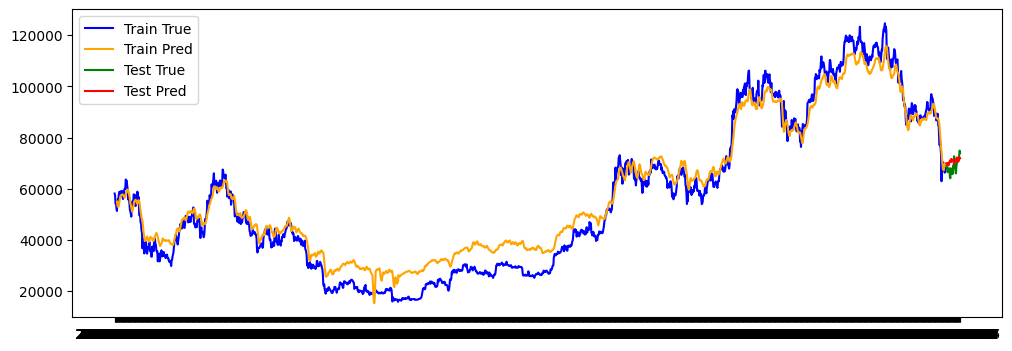

In [11]:
btc_month = model_creation(btc_5years, steps = 30, lookback = 5, n_features = btc_5years.shape[1], batch_size = 30, epochs = 100)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0548 - mae: 0.1829 - val_loss: 0.0531 - val_mae: 0.1942
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0673 - mae: 0.1945 - val_loss: 0.3153 - val_mae: 0.5519
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0442 - mae: 0.1676 - val_loss: 0.1957 - val_mae: 0.4296
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0323 - mae: 0.1405 - val_loss: 0.1111 - val_mae: 0.3132
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0275 - mae: 0.1267 - val_loss: 0.0856 - val_mae: 0.2684
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0252 - mae: 0.1229 - val_loss: 0.0824 - val_mae: 0.2645
MAPE = 0.2110
MAE = 19456.1251


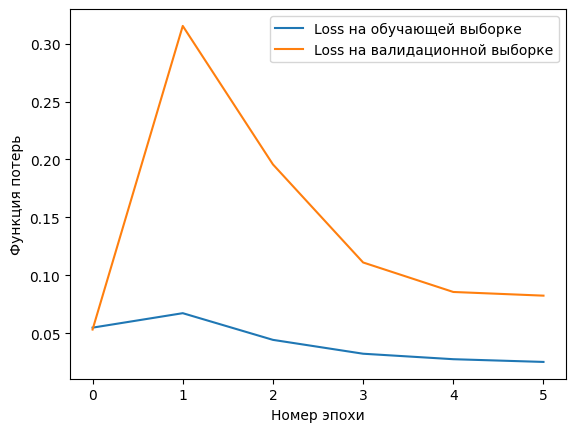

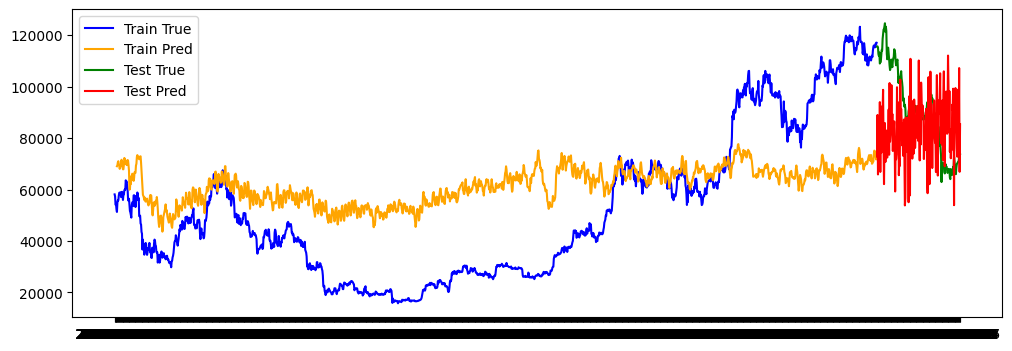

In [12]:
btc_halfyear = model_creation(btc_5years, steps = 180, lookback = 5, n_features = btc_5years.shape[1], batch_size = 30, epochs = 100)

Лучшие метрики битка

BTC Месяц:
MAPE = 0.2323
MAE = 16046.5455
lb = 5, bs = 30

BTC Полгода:
MAPE = 0.1837
MAE = 18769.6258
lb = 20 bs = 30

MAPE = 0.1454
MAE = 14768.9463
lb = 5 bs = 30

MAPE = 0.1273
MAE = 12845.0760
lb = 5 bs = 30
2 скрытых слоя, 64 нейрона

In [13]:
eth_month = model_creation(eth_5years, steps = 30, lookback = 700, n_features = btc_5years.shape[1], batch_size = 5, epochs = 100)

Epoch 1/100
154/192 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - loss: 0.0326 - mae: 0.1477

KeyboardInterrupt: 

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.1880 - mae: 0.3672 - val_loss: 0.1744 - val_mae: 0.3706
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1545 - mae: 0.3151 - val_loss: 0.1006 - val_mae: 0.2512
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1225 - mae: 0.2722 - val_loss: 0.0689 - val_mae: 0.2014
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0966 - mae: 0.2397 - val_loss: 0.0556 - val_mae: 0.1795
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0822 - mae: 0.2210 - val_loss: 0.0461 - val_mae: 0.1649
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0732 - mae: 0.2094 - val_loss: 0.0444 - val_mae: 0.1613
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0679 - mae: 0.2009 - val_loss: 0.0433 - val_mae: 0.1594
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0630 - mae: 0.1932 - val_loss: 0.0429 - val_mae: 0.1609
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0612 - mae: 

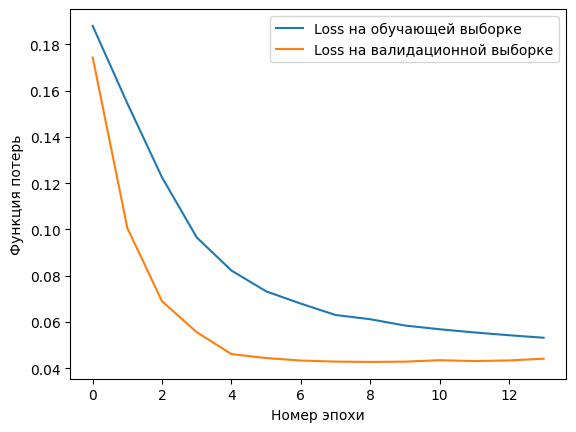

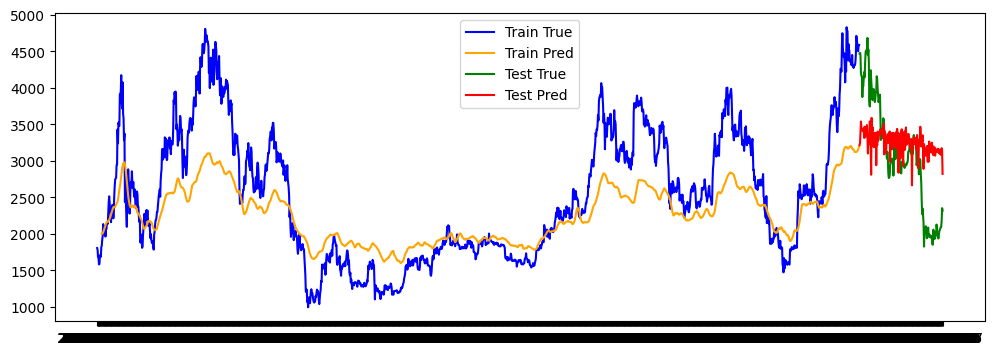

In [14]:
eth_halfyear = model_creation(eth_5years, steps = 180, lookback = 10, n_features = btc_5years.shape[1], batch_size = 150, epochs = 100)

Лучшие метрики эфира
ETH Месяц:

MAPE = 0.1324,
MAE = 298.1904,
lb = 500, bs = 10

MAPE = 0.0916,
MAE = 226.9533,
lb = 700, bs = 5, 2 скрытых слоя по 128 и 64

ETH Полгода:
MAPE = 0.1615
MAE = 562.2565
lb = 150, bs = 100, 2 скрытых слоя 256 0.5 и 64 0.1

MAPE = 0.1413
MAE = 406.4251
lb = 200, bs = 100, 2 скр 32 0.5 32 0.1

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - loss: 0.0296 - mae: 0.1244 - val_loss: 0.4407 - val_mae: 0.6521
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0277 - mae: 0.1171 - val_loss: 0.4255 - val_mae: 0.6404
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0256 - mae: 0.1097 - val_loss: 0.4077 - val_mae: 0.6263
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0234 - mae: 0.1022 - val_loss: 0.3866 - val_mae: 0.6091
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0210 - mae: 0.0947 - val_loss: 0.3614 - val_mae: 0.5878
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0187 - mae: 0.0881 - val_loss: 0.3318 - val_mae: 0.5618
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0164 - mae: 0.0831 - val_loss: 0.2984 - val_mae: 0.5308
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0146 - mae: 0.0808 - val_loss: 0.2637 - val_mae: 0.4967
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0135 - mae:

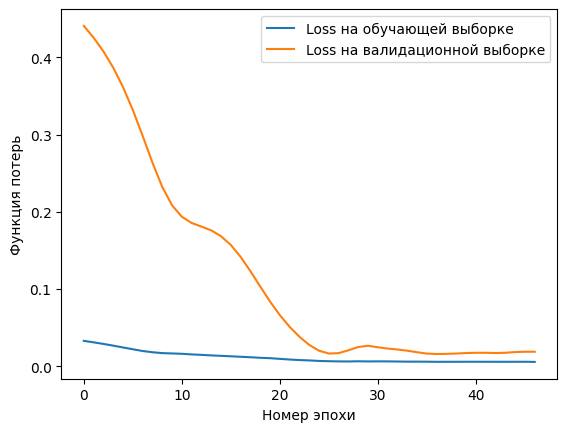

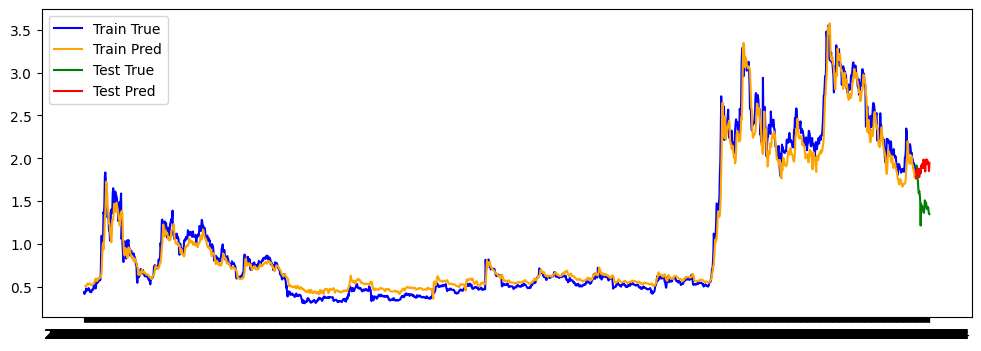

In [ ]:
xrp_month = model_creation(xrp_5years, steps = 30, lookback = 3, n_features = btc_5years.shape[1], batch_size = 500, epochs = 100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 537ms/step - loss: 0.0143 - mae: 0.0933 - val_loss: 0.2775 - val_mae: 0.4454
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0139 - mae: 0.0908 - val_loss: 0.2752 - val_mae: 0.4428
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0134 - mae: 0.0882 - val_loss: 0.2727 - val_mae: 0.4399
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0129 - mae: 0.0855 - val_loss: 0.2699 - val_mae: 0.4367
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0124 - mae: 0.0826 - val_loss: 0.2668 - val_mae: 0.4330
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0118 - mae: 0.0795 - val_loss: 0.2631 - val_mae: 0.4288
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0112 - mae: 0.0762 - val_loss: 0.2589 - val_mae: 0.4238
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0105 - mae: 0.0728 - val_loss: 0.2540 - val_mae: 0.4179
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0097 - 

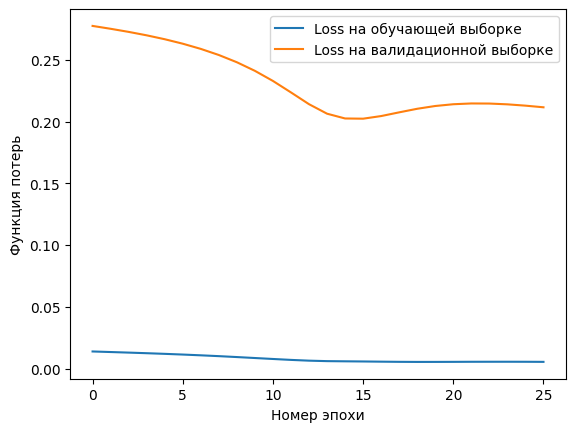

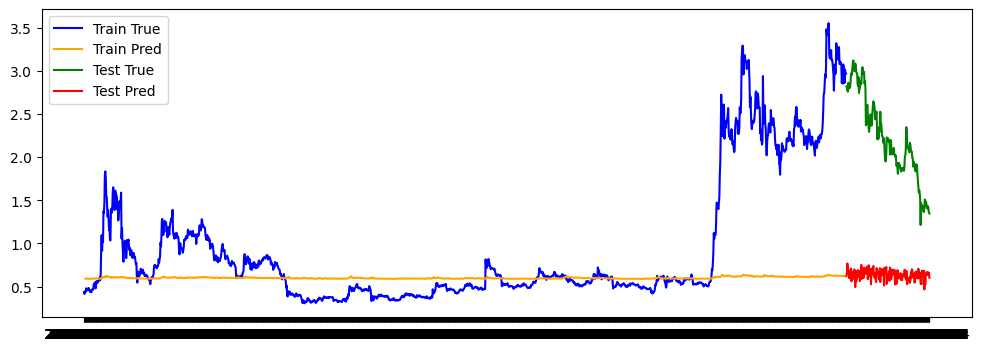

In [ ]:
xrp_halfyear = model_creation(xrp_5years, steps = 180, lookback = 3, n_features = btc_5years.shape[1], batch_size = 1000, epochs = 100)

Лучшие метрики рипла

XRP Месяц:
MAPE = 0.2888
MAE = 0.4127
lb = 3, bs = 1500, 2 скр по 64 0.5 32 0.1

MAPE = 0.2268
MAE = 0.3287
lb = 3, bs = 500 2 скр по 64 0.5 32 0.1

XRP Полгода:

MAPE = 0.1588
MAE = 0.3626
lb = 3, bs = 100, 2 скр по 64 0.5 64 0.1

MAPE = 0.1518
MAE = 0.3370
lb = 1, bs = 25, 2 скр по 64 0.5 64 0.1

MAPE = 0.1508
MAE = 0.3403
lb = 2, bs = 25, 2 скр по 64 0.5 64 0.1

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 774ms/step - loss: 0.0346 - mae: 0.1447 - val_loss: 0.0242 - val_mae: 0.1472
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 629ms/step - loss: 0.0315 - mae: 0.1365 - val_loss: 0.0226 - val_mae: 0.1419
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 651ms/step - loss: 0.0298 - mae: 0.1318 - val_loss: 0.0223 - val_mae: 0.1412
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 668ms/step - loss: 0.0288 - mae: 0.1285 - val_loss: 0.0207 - val_mae: 0.1356
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 680ms/step - loss: 0.0277 - mae: 0.1246 - val_loss: 0.0195 - val_mae: 0.1311
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 653ms/step - loss: 0.0265 - mae: 0.1206 - val_loss: 0.0185 - val_mae: 0.1274
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 670ms/step - loss: 0.0256 - mae: 0.1165 - val_loss: 0.0176 - val_mae: 0.1242
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 707ms/step - loss: 0.0246 - mae: 0.1130 - val_loss: 0.0166 - val_mae: 0.1200
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 691ms/step - loss: 0.023

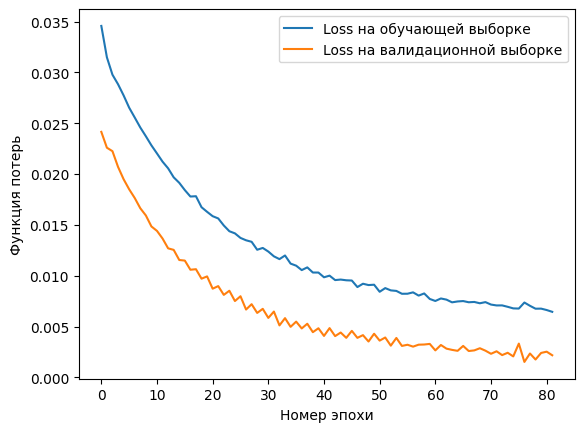

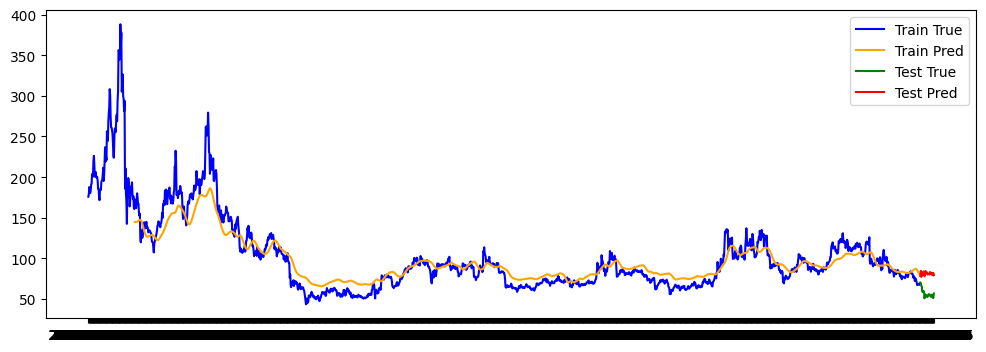

In [25]:
ltc_month = model_creation(ltc_5years, steps = 30, lookback = 100, n_features = btc_5years.shape[1], batch_size = 500, epochs = 100)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 396ms/step - loss: 0.0111 - mae: 0.0900 - val_loss: 0.0209 - val_mae: 0.1364
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 387ms/step - loss: 0.0076 - mae: 0.0693 - val_loss: 0.0149 - val_mae: 0.1124
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 384ms/step - loss: 0.0054 - mae: 0.0561 - val_loss: 0.0109 - val_mae: 0.0927
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 387ms/step - loss: 0.0042 - mae: 0.0487 - val_loss: 0.0093 - val_mae: 0.0841
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 378ms/step - loss: 0.0036 - mae: 0.0457 - val_loss: 0.0081 - val_mae: 0.0771
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 380ms/step - loss: 0.0033 - mae: 0.0440 - val_loss: 0.0076 - val_mae: 0.0739
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 376ms/step - loss: 0.0032 - mae: 0.0435 - val_loss: 0.0071 - val_mae: 0.0704
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 381ms/step - loss: 0.0030 - mae: 0.0426 - val_loss: 0.0068 - val_mae: 0.0685
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 377ms

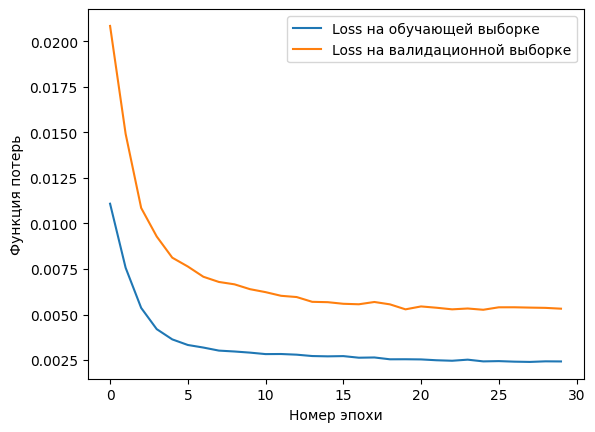

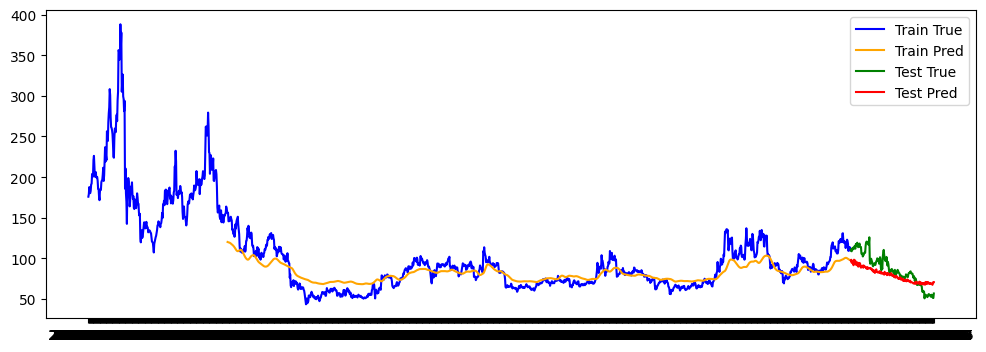

In [43]:
ltc_halfyear = model_creation(ltc_5years, steps = 180, lookback = 300, n_features = btc_5years.shape[1], batch_size = 50, epochs = 200)

ЛУЧШИЕ МЕТРИКИ ЛАЙТКОИН

LTC Месяц:

MAPE = 0.3288
MAE = 18.1267
lb = 2, bs = 1500, 4 скр 256 0.1 128 0.1 64 0.1 32 0.1

MAPE = 0.2312
MAE = 12.6511
lb = 3, bs = 50, 4 скр 256 0.5 128 0.4 64 0.3 32 0.2 16 0.1


LTC ПОЛГОДА:

MAPE = 0.2158
MAE = 19.2847
lb = 500, bs = 500, 3 скр 128 0.1 32 0.5 16 0.7

MAPE = 0.2072
MAE = 17.3385
lb = 250, bs = 500, 3 скр 128 0.1 32 0.5 16 0.7

MAPE = 0.1461
MAE = 11.9180
lb = 250, bs = 100, 3 скр 128 0.1 32 0.5 16 0.7

GRU

In [4]:
def gru(X_train, y_train, steps, n_features, b_size, e):
  tf.keras.backend.clear_session()

  model = Sequential()
  model.add(Input((X_train.shape[1], n_features)))
  model.add(GRU(32, return_sequences = True))
  model.add(Dropout(0.2))
#   model.add(GRU(32, return_sequences = True))
#   model.add(Dropout(0.5))
  model.add(GRU(16, return_sequences = False))
  model.add(Dropout(0.8))
  model.add(Dense(steps))

  model.compile(
      optimizer = 'adam',
      loss = 'mean_squared_error',
      metrics = ['mae']
  )

  early_stopping = EarlyStopping(
      monitor = 'val_loss',
      patience = 5,
      restore_best_weights = True
  )

  history = model.fit(
      X_train, y_train,
      validation_split = 0.1, #поробовать просто 0.1 или 0.2
      batch_size = b_size,
      epochs = e,
      shuffle = False,
      callbacks = [early_stopping]

  )

  plt.plot(history.history["loss"], label="Loss на обучающей выборке")
  plt.plot(history.history["val_loss"], label="Loss на валидационной выборке")
  plt.xlabel("Номер эпохи")
  plt.ylabel("Функция потерь")
  plt.legend();

  return model

def gru_model_creation(coin, steps, lookback, n_features, batch_size, epochs):
  train, test, scaler = split_norm(coin, steps)
  X_train, y_train = make_sequences(train, lookback, steps)

  model = gru(X_train, y_train, steps=steps, n_features=n_features, b_size=batch_size, e=epochs)

  # прогнозы
  true_test, pred_test = make_predict(model, train, test, lookback, steps, scaler)
  model_train = predict_train(model, train, lookback, scaler)

  # метрика
  mape = mean_absolute_percentage_error(true_test, pred_test)
  mae = mean_absolute_error(true_test, pred_test)
  print(f'MAPE = {mape:.4f}')
  print(f'MAE = {mae:.4f}')

  plt.figure(figsize=(12,4))

  # # фактический close train
  plt.plot(coin['close'].iloc[:len(train)], label='Train True', color='blue')

  # прогноз train
  plt.plot(pd.Series(model_train, index=range(lookback, len(train))), label='Train Pred', color='orange')

  # фактический close test
  plt.plot(coin['close'].iloc[len(train):len(train)+len(test)], label='Test True', color='green')

  # прогноз test
  plt.plot(pd.Series(pred_test, index=range(len(train), len(train)+steps)), label='Test Pred', color='red')

  plt.legend()
  plt.grid(False)
  plt.show()

  return model


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - loss: 0.1729 - mae: 0.3224 - val_loss: 0.6006 - val_mae: 0.7662
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - loss: 0.1539 - mae: 0.3000 - val_loss: 0.5314 - val_mae: 0.7179
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - loss: 0.1427 - mae: 0.2836 - val_loss: 0.4901 - val_mae: 0.6883
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - loss: 0.1326 - mae: 0.2669 - val_loss: 0.4443 - val_mae: 0.6527
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - loss: 0.1229 - mae: 0.2509 - val_loss: 0.3911 - val_mae: 0.6086
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - loss: 0.1132 - mae: 0.2353 - val_loss: 0.3443 - val_mae: 0.5678
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - loss: 0.1072 - mae: 0.2254 - val_loss: 0.3048 - val_mae: 0.5317
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - loss: 0.0999 - mae: 0.2134 - val_loss: 0.2655 - val_mae: 0.4926
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/

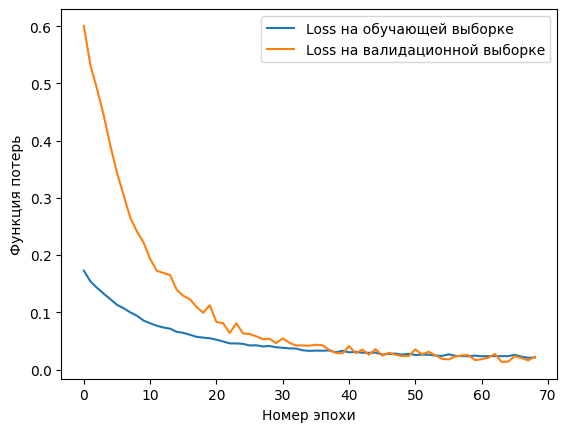

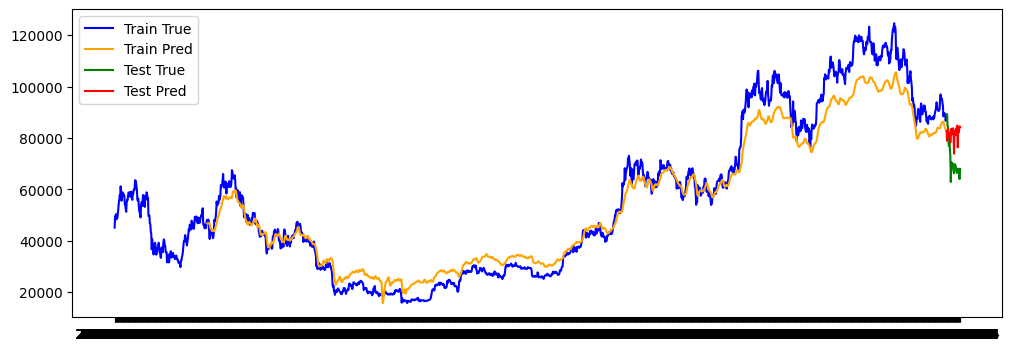

In [35]:
gru_btc_month = gru_model_creation(btc_5years, steps = 30, lookback = 200, n_features = btc_5years.shape[1], batch_size = 150, epochs = 100)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0857 - mae: 0.2301 - val_loss: 0.4732 - val_mae: 0.6793
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0656 - mae: 0.1957 - val_loss: 0.3601 - val_mae: 0.5891
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0521 - mae: 0.1725 - val_loss: 0.2658 - val_mae: 0.5030
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0421 - mae: 0.1533 - val_loss: 0.1897 - val_mae: 0.4211
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0340 - mae: 0.1373 - val_loss: 0.1266 - val_mae: 0.3389
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0306 - mae: 0.1283 - val_loss: 0.1025 - val_mae: 0.3034
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0289 - mae: 0.1239 - val_loss: 0.1041 - val_mae: 0.3077
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0255 - mae: 0.1173 - val_loss: 0.0907 - val_mae: 0.2856
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.02

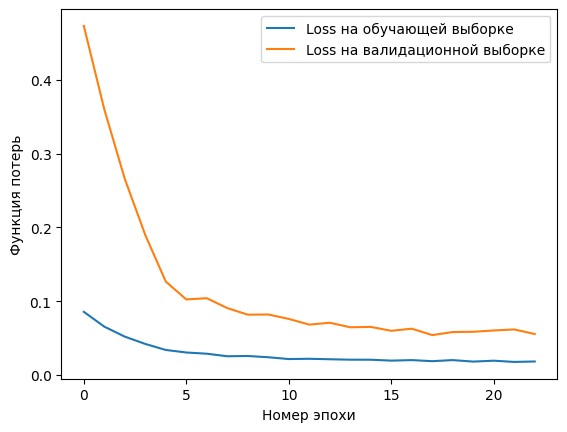

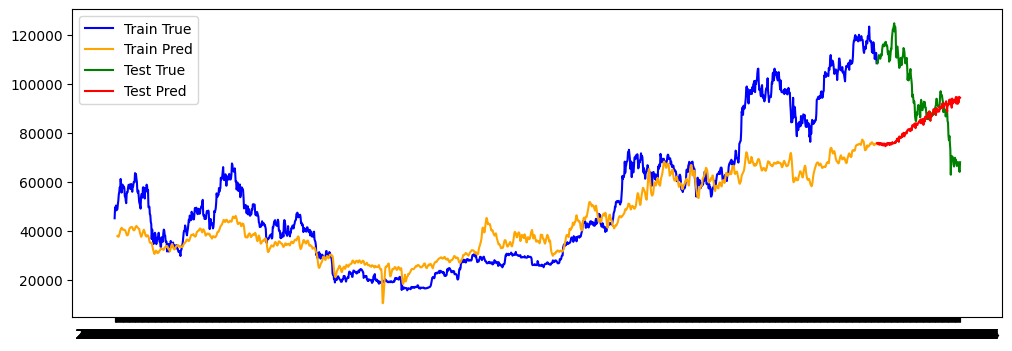

In [ ]:
gru_btc_halfyear = gru_model_creation(btc_5years, steps = 180, lookback = 6, n_features = btc_5years.shape[1], batch_size = 40, epochs = 100)

GRU БИТКОИН:

МЕСЯЦ:
MAPE = 0.1474
MAE = 10171.5806
lb = 150, bs = 150, 2 скр 128 0.1 16 0.8

MAPE = 0.1321
MAE = 9322.9745
lb = 200, bs = 150, 2 скр 64 0.1 16 0.8


ПОЛГОДА:

MAPE = 0.1860
MAE = 17856.3852
lb = 20, bs = 50, 2 скр 64 0.1 32 0.8

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - loss: 0.2076 - mae: 0.3880 - val_loss: 0.5287 - val_mae: 0.7077
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1907 - mae: 0.3707 - val_loss: 0.4997 - val_mae: 0.6871
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1828 - mae: 0.3594 - val_loss: 0.4788 - val_mae: 0.6713
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.1757 - mae: 0.3490 - val_loss: 0.4628 - val_mae: 0.6591
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1707 - mae: 0.3406 - val_loss: 0.4499 - val_mae: 0.6496
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1663 - mae: 0.3354 - val_loss: 0.4381 - val_mae: 0.6408
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1614 - mae: 0.3290 - val_loss: 0.4251 - val_mae: 0.6307
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1570 - mae: 0.3223 - val_loss: 0.4108 - val_mae: 0.6191
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.1524 - mae:

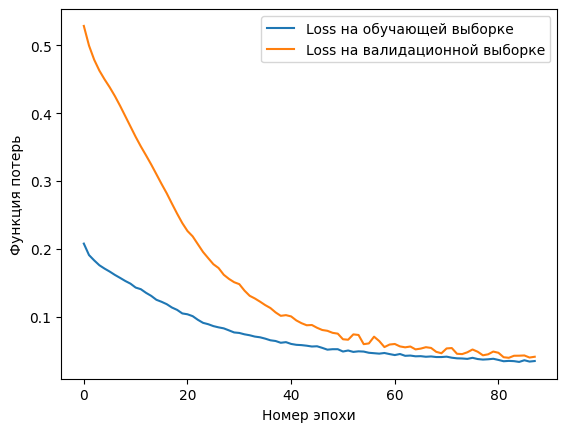

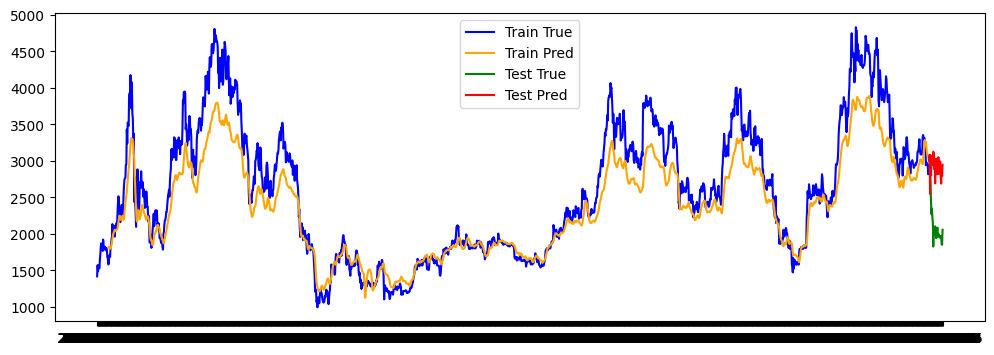

In [121]:
gru_eth_month = gru_model_creation(eth_5years, steps = 30, lookback = 25, n_features = eth_5years.shape[1], batch_size = len(eth_5years) // 4, epochs = 150)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - loss: 0.1954 - mae: 0.3735 - val_loss: 0.1912 - val_mae: 0.3982
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.1860 - mae: 0.3628 - val_loss: 0.1810 - val_mae: 0.3852
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.1772 - mae: 0.3501 - val_loss: 0.1678 - val_mae: 0.3664
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.1678 - mae: 0.3355 - val_loss: 0.1505 - val_mae: 0.3400
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.1556 - mae: 0.3168 - val_loss: 0.1304 - val_mae: 0.3081
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.1452 - mae: 0.3014 - val_loss: 0.1112 - val_mae: 0.2767
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.1329 - mae: 0.2851 - val_loss: 0.0953 - val_mae: 0.2504
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.1217 - mae: 0.2707 - val_loss: 0.0828 - val_mae: 0.2295
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.1129 - mae:

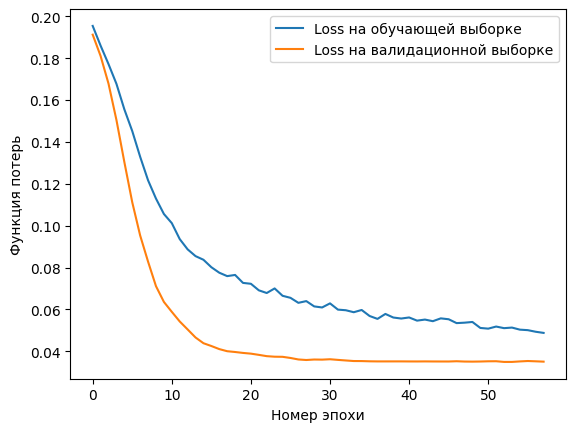

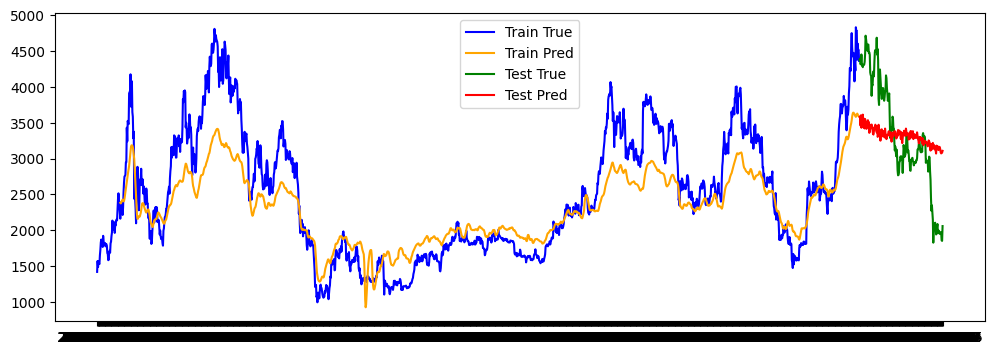

In [134]:
gru_eth_halfyear = gru_model_creation(eth_5years, steps = 180, lookback = 50, n_features = eth_5years.shape[1], batch_size = len(eth_5years) // 10, epochs = 100)

ЭФИР МЕСЯЦ:

MAPE = 0.1533
MAE = 346.8224
lb = 2, bs = len(eth_5years), 2 скр 64 0.1 32 0.8

MAPE = 0.1263
MAE = 297.1371
lb = 70, bs = len(eth_5years), 2 скр 32 0.1 16 0.8

ЭФИР ПОЛГОДА:

MAPE = 0.1588
MAE = 513.1541
lb = 6, bs = 40, 2 скр 32 0.1 16 0.8

MAPE = 0.1471
MAE = 493.8034
lb = 20, bs = 20, 2 скр 32 0.1 16 0.8



Epoch 1/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - loss: 0.0805 - mae: 0.1829 - val_loss: 0.4809 - val_mae: 0.6758
Epoch 2/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0763 - mae: 0.1745 - val_loss: 0.4652 - val_mae: 0.6647
Epoch 3/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0738 - mae: 0.1706 - val_loss: 0.4518 - val_mae: 0.6550
Epoch 4/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0719 - mae: 0.1682 - val_loss: 0.4402 - val_mae: 0.6464
Epoch 5/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0700 - mae: 0.1663 - val_loss: 0.4298 - val_mae: 0.6386
Epoch 6/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0688 - mae: 0.1640 - val_loss: 0.4200 - val_mae: 0.6309
Epoch 7/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0672 - mae: 0.1615 - val_loss: 0.4103 - val_mae: 0.6231
Epoch 8/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0660 - mae: 0.1590 - val_loss: 0.4007 - val_mae: 0.6153
Epoch 9/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0641 - mae:

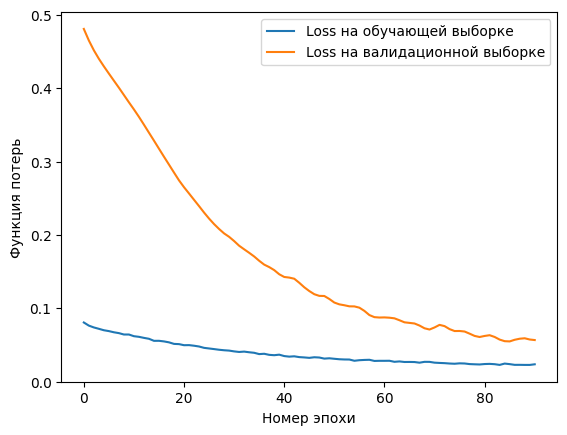

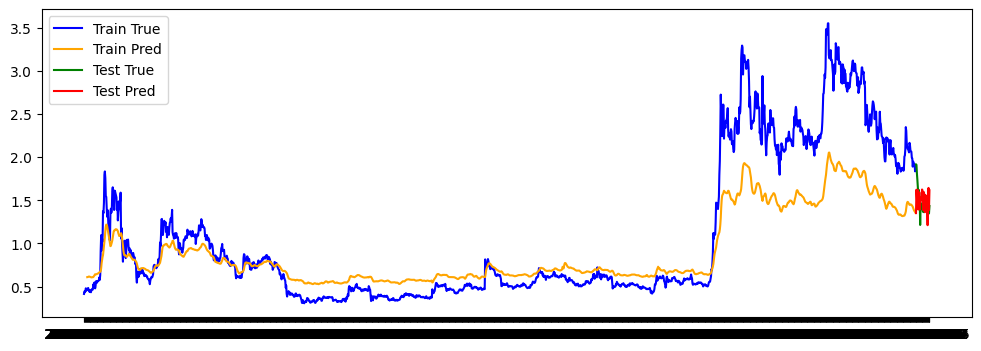

In [152]:
gru_xrp_month = gru_model_creation(xrp_5years, steps = 30, lookback = 7, n_features = eth_5years.shape[1], batch_size = len(xrp_5years) // 3, epochs = 150)

Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0277 - mae: 0.1043 - val_loss: 0.3730 - val_mae: 0.5934
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0242 - mae: 0.0905 - val_loss: 0.3415 - val_mae: 0.5663
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0217 - mae: 0.0821 - val_loss: 0.3119 - val_mae: 0.5398
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0201 - mae: 0.0780 - val_loss: 0.2900 - val_mae: 0.5193
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0189 - mae: 0.0753 - val_loss: 0.2705 - val_mae: 0.5004
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0184 - mae: 0.0748 - val_loss: 0.2533 - val_mae: 0.4831
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0175 - mae: 0.0724 - val_loss: 0.2389 - val_mae: 0.4676
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0173 - mae: 0.0729 - val_loss: 0.2200 - val_mae: 0.4464
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - los

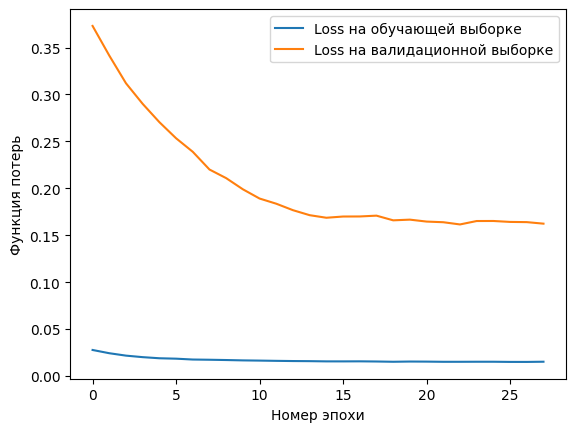

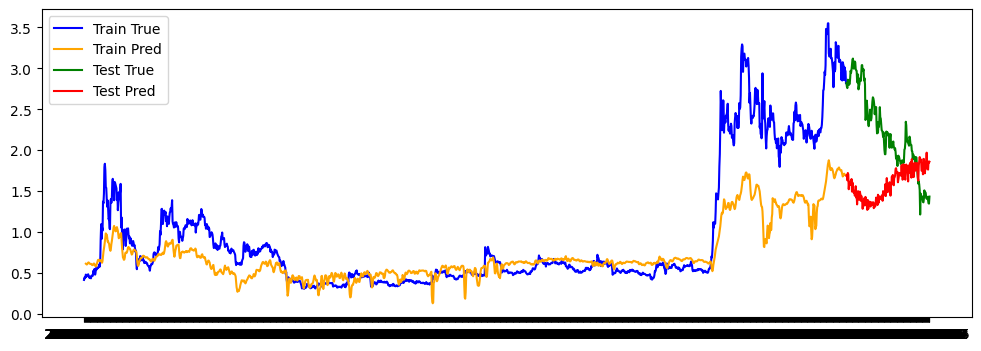

In [187]:
gru_xrp_halfyear = gru_model_creation(xrp_5years, steps = 180, lookback = 4, n_features = eth_5years.shape[1], batch_size = len(xrp_5years) // 30, epochs = 200)

рипл 

МЕСЯЦ

MAPE = 0.0804
MAE = 0.1225
lb = 10, bs = len // 3, 2 скр 32 0.1 16 0.8

MAPE = 0.1128
MAE = 0.1679
lb = 10, bs = len // 5, 2 скр 32 0.1 16 0.8


ПОЛГОДА

MAPE = 0.2704
MAE = 0.6566
lb = 5, bs = len // 35, 2 скр 32 0.1 16 0.8

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 979ms/step - loss: 0.0344 - mae: 0.1417 - val_loss: 0.0264 - val_mae: 0.1535
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step - loss: 0.0303 - mae: 0.1336 - val_loss: 0.0238 - val_mae: 0.1458
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step - loss: 0.0282 - mae: 0.1273 - val_loss: 0.0218 - val_mae: 0.1392
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step - loss: 0.0268 - mae: 0.1240 - val_loss: 0.0204 - val_mae: 0.1340
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step - loss: 0.0254 - mae: 0.1202 - val_loss: 0.0193 - val_mae: 0.1299
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step - loss: 0.0247 - mae: 0.1184 - val_loss: 0.0185 - val_mae: 0.1267
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step - loss: 0.0241 - mae: 0.1160 - val_loss: 0.0179 - val_mae: 0.1242
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step - loss: 0.0232 - mae: 0.1132 - val_loss: 0.0174 - val_mae: 0.1220
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step - loss: 0.022

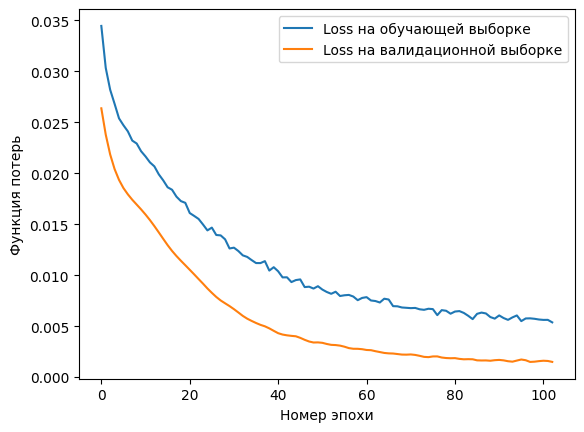

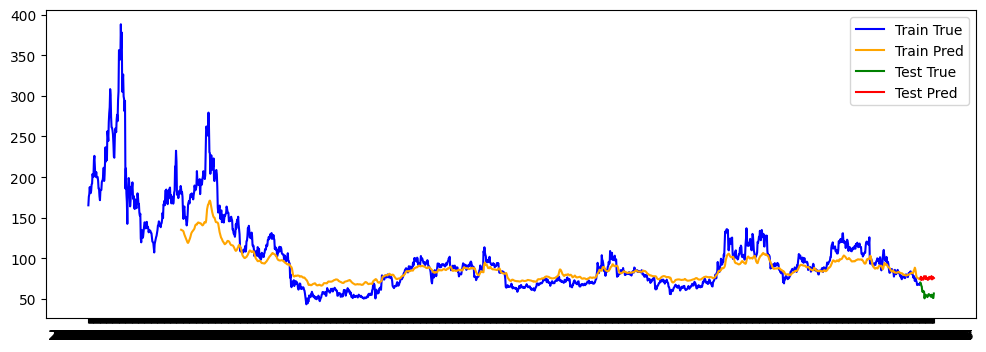

In [43]:
gru_ltc_month = gru_model_creation(ltc_5years, steps = 30, lookback = 200, n_features = ltc_5years.shape[1], batch_size = len(ltc_5years) // 2, epochs = 200)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0142 - mae: 0.0991 - val_loss: 0.0227 - val_mae: 0.1428
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0111 - mae: 0.0840 - val_loss: 0.0183 - val_mae: 0.1261
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0088 - mae: 0.0709 - val_loss: 0.0145 - val_mae: 0.1100
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0071 - mae: 0.0619 - val_loss: 0.0118 - val_mae: 0.0971
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0059 - mae: 0.0553 - val_loss: 0.0098 - val_mae: 0.0861
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0052 - mae: 0.0520 - val_loss: 0.0087 - val_mae: 0.0799
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0046 - mae: 0.0490 - val_loss: 0.0075 - val_mae: 0.0727
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0044 - mae: 0.0480 - val_loss: 0.0071 - val_mae: 0.0698
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step -

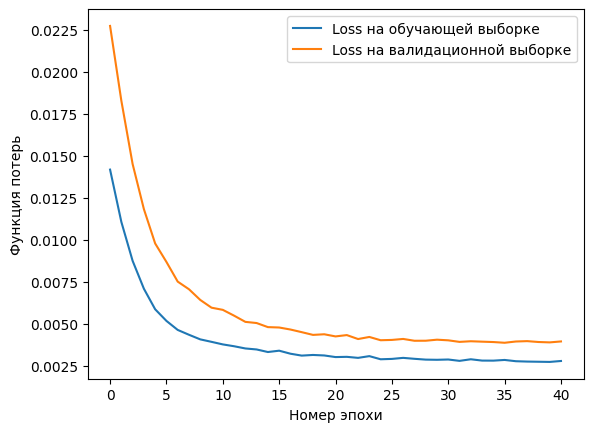

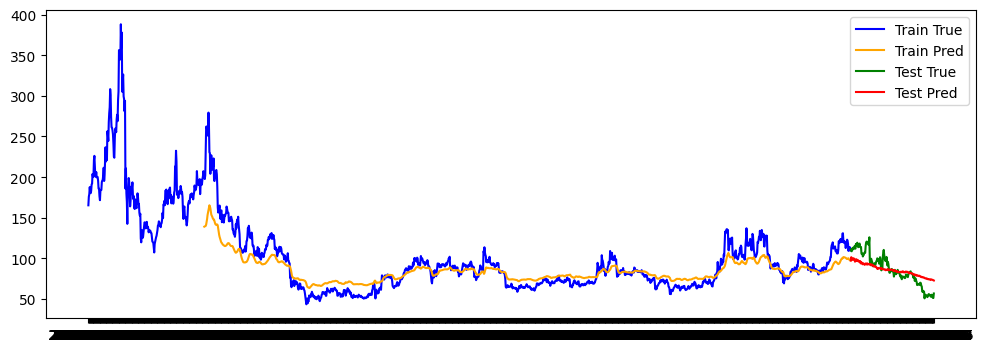

In [22]:
gru_ltc_halfyear = gru_model_creation(ltc_5years, steps = 180, lookback = 250, n_features = ltc_5years.shape[1], batch_size = len(ltc_5years) // 25, epochs = 200)

ЛАЙТКОИН

месяц

MAPE = 0.3572
MAE = 19.5573
lb = 20, bs = len // 3, 2 скр 32 0.2 16 0.8

MAPE = 0.3310
MAE = 18.1983
lb = 50, bs = len // 2, 2 скр 32 0.2 16 0.8

MAPE = 0.3448
MAE = 18.9932
lb = 200, bs = len // 2, 2 скр 32 0.2 16 0.8

пол года

MAPE = 0.2010
MAE = 14.6930
lb = 4, bs = len // 30, 2 скр 32 0.2 16 0.8

MAPE = 0.1374
MAE = 11.2019
lb = 250, bs = len // 30, 2 скр 32 0.2 16 0.8

MAPE = 0.1288
MAE = 10.3938
lb = 250, bs = len // 25, 2 скр 32 0.2 16 0.8

**TCN**!

In [20]:
def tcn_model(X_train, y_train, steps, n_features, b_size, e):

    tf.keras.backend.clear_session()

    model = Sequential()
    model.add(Input((X_train.shape[1], n_features)))

    model.add(TCN(
        nb_filters = 32,
        kernel_size = 5,
        dilations = [1, 2, 4, 8, 16, 32, 64],
        padding = 'causal',
        return_sequences = False,
        dropout_rate = 0.4
    ))
    model.add(Dense(64, activation='elu'))
    model.add(Dropout(0.7))
    model.add(Dense(steps))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae']
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        batch_size=b_size,
        epochs=e,
        shuffle=False,
        callbacks=[early_stopping]
    )

    plt.plot(history.history["loss"], label="Loss train")
    plt.plot(history.history["val_loss"], label="Loss val")
    plt.legend()
    plt.show()

    return model

def tcn_model_creation(coin, steps, lookback, n_features, batch_size, epochs):
  train, test, scaler = split_norm(coin, steps)
  X_train, y_train = make_sequences(train, lookback, steps)

  model = tcn_model(X_train, y_train, steps=steps, n_features=n_features, b_size=batch_size, e=epochs)

  # прогнозы
  true_test, pred_test = make_predict(model, train, test, lookback, steps, scaler)
  model_train = predict_train(model, train, lookback, scaler)

  # метрика
  mape = mean_absolute_percentage_error(true_test, pred_test)
  mae = mean_absolute_error(true_test, pred_test)
  print(f'MAPE = {mape:.4f}')
  print(f'MAE = {mae:.4f}')

  plt.figure(figsize=(12,4))

  # # фактический close train
  plt.plot(coin['close'].iloc[:len(train)], label='Train True', color='blue')

  # прогноз train
  plt.plot(pd.Series(model_train, index=range(lookback, len(train))), label='Train Pred', color='orange')

  # фактический close test
  plt.plot(coin['close'].iloc[len(train):len(train)+len(test)], label='Test True', color='green')

  # прогноз test
  plt.plot(pd.Series(pred_test, index=range(len(train), len(train)+steps)), label='Test Pred', color='red')

  plt.legend()
  plt.grid(False)
  plt.show()

  return model

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 489ms/step - loss: 0.8388 - mae: 0.7004 - val_loss: 0.6253 - val_mae: 0.7155
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.5647 - mae: 0.5728 - val_loss: 0.5609 - val_mae: 0.6990
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.4067 - mae: 0.4812 - val_loss: 0.5232 - val_mae: 0.6909
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.2929 - mae: 0.4085 - val_loss: 0.5002 - val_mae: 0.6843
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.2326 - mae: 0.3623 - val_loss: 0.4866 - val_mae: 0.6795
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.1861 - mae: 0.3215 - val_loss: 0.4775 - val_mae: 0.6758
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.1579 - mae: 0.2945 - val_loss: 0.4706 - val_mae: 0.6725
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.1425 - mae: 0.2803 - val_loss: 0.4651 - val_mae: 0.6696
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.123

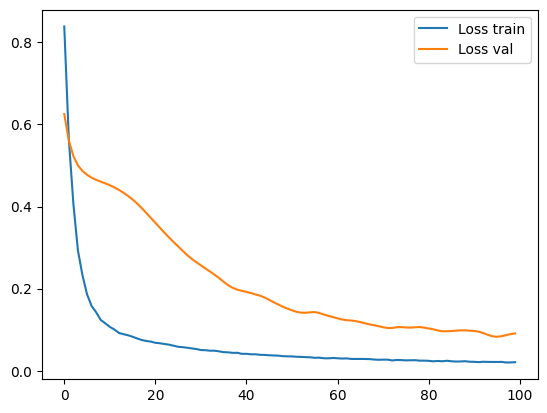

MAPE = 0.2863
MAE = 19724.3943


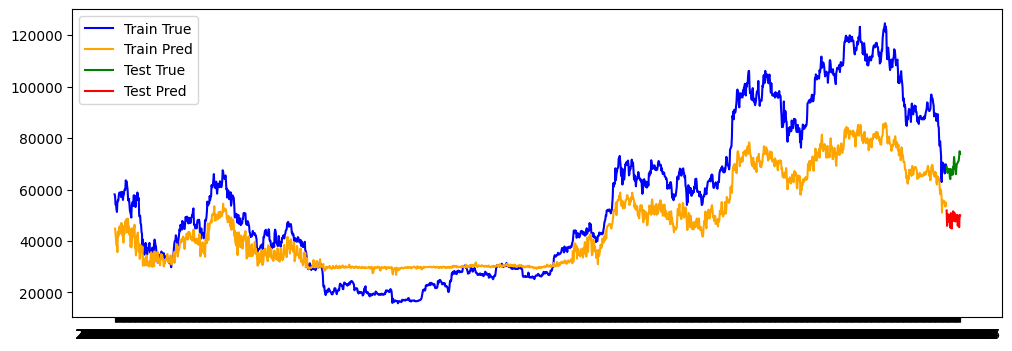

In [21]:
tcn_btc_month = tcn_model_creation(btc_5years, steps = 30, lookback = 1, n_features = btc_5years.shape[1], batch_size = len(btc_5years) // 2, epochs = 100)

Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x000001898A15CAE0>
Traceback (most recent call last):
  File "C:\Users\pinea\AppData\Local\Programs\Python\Python312\Lib\weakref.py", line 370, in remove
    self = selfref()
           ^^^^^^^^^
KeyboardInterrupt: 


Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0858 - mae: 0.2346 - val_loss: 0.4709 - val_mae: 0.6616
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0781 - mae: 0.2230 - val_loss: 0.4570 - val_mae: 0.6527
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0719 - mae: 0.2130 - val_loss: 0.4458 - val_mae: 0.6451
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0674 - mae: 0.2058 - val_loss: 0.4362 - val_mae: 0.6382
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0634 - mae: 0.1989 - val_loss: 0.4274 - val_mae: 0.6316
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0604 - mae: 0.1934 - val_loss: 0.4186 - val_mae: 0.6246
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0576 - mae: 0.1880 - val_loss: 0.4092 - val_mae: 0.6169
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0550 - mae: 0.1826 - val_loss: 0.3990 - val_mae: 0.6083
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0528 -

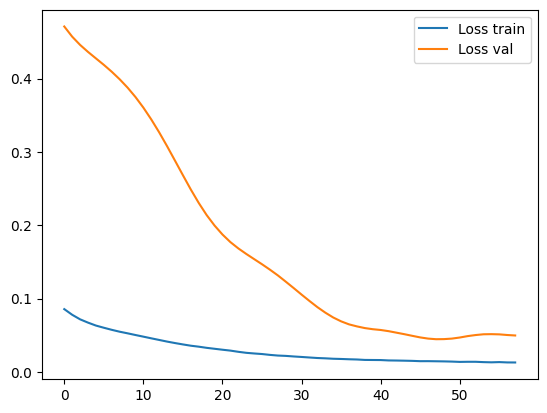

MAPE = 0.1716
MAE = 15524.9684


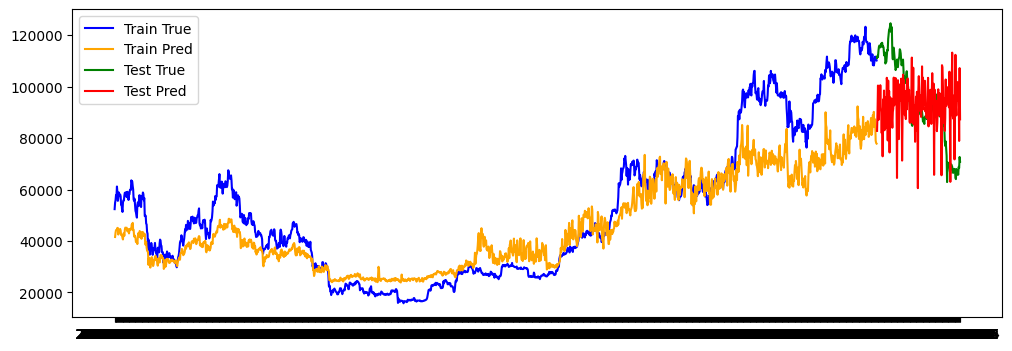

In [ ]:
tcn_btc_halfyear = tcn_model_creation(btc_5years, steps = 180, lookback = 1, n_features = btc_5years.shape[1], batch_size = len(btc_5years) // 2, epochs = 200)

Биток месяц:

MAPE = 0.1935
MAE = 13389.6921
lb = 1, bs = len//1, nb = 128, ker = 5, dil = 1, 2, 4, 8, 16, 32

MAPE = 0.1364
MAE = 9514.9972
lb = 1, bs = len//1, nb = 64, ker = 4, dil = 1, 2, 4, 8, 16, 32, 64

MAPE = 0.0930
MAE = 6971.5202
lb = 1, bs = len//2, nb = 32, ker = 5, dil = 1, 2, 4, 8, 16, 32, 64, dense = elu 64 0.7

Биток полгода:

MAPE = 0.2013
MAE = 20214.9798
lb = 1, bs = len//1, nb = 64, ker = 7, dil = 1, 2, 4, 8, 16, 32, , dense = elu 16 0.7



НЕ СПОСОБНА К НОРМ ПРОГНОЗУ


In [24]:
tcn_eth_month = tcn_model_creation(eth_5years, steps = 30, lookback = 1, n_features = eth_5years.shape[1], batch_size = len(eth_5years) // 3, epochs = 100)

Epoch 1/100


KeyboardInterrupt: 

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3581 - mae: 0.4614 - val_loss: 0.3030 - val_mae: 0.4790
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.3122 - mae: 0.4302 - val_loss: 0.2753 - val_mae: 0.4580
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.2744 - mae: 0.4046 - val_loss: 0.2534 - val_mae: 0.4408
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.2463 - mae: 0.3838 - val_loss: 0.2357 - val_mae: 0.4265
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.2227 - mae: 0.3651 - val_loss: 0.2213 - val_mae: 0.4144
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.2052 - mae: 0.3499 - val_loss: 0.2094 - val_mae: 0.4041
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.1898 - mae: 0.3372 - val_loss: 0.1994 - val_mae: 0.3949
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.1758 - mae: 0.3248 - val_loss: 0.1908 - val_mae: 0.3865
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1667 - mae: 0.

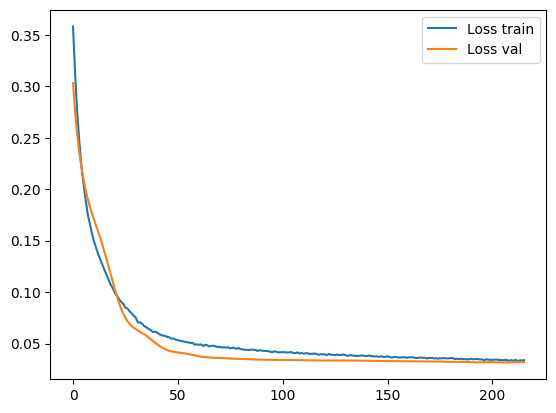

MAPE = 0.1782
MAE = 494.1729


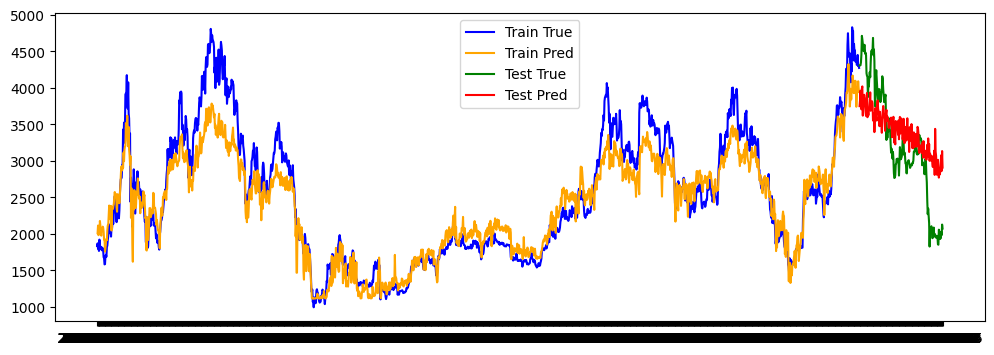

In [79]:
tcn_eth_halfyear = tcn_model_creation(eth_5years, steps = 180, lookback = 1, n_features = eth_5years.shape[1], batch_size = len(eth_5years) // 1, epochs = 300)

ЭФИР

МЕСЯЦ:

MAPE = 0.2548
MAE = 525.8850
lb = 1, bs = len//1, nb = 128, ker = 2, dil = 1, 2, 4, dense = elu 16 0.2

MAPE = 0.0627
MAE = 123.1326
lb = 1, bs = len//3, nb = 128, ker = 2, dil = 1, 3, 9, dense = elu 64 0.7

ПОЛГОДА:

MAPE = 0.1547
MAE = 458.7949
lb = 1, bs = len//1, nb = 32, ker = 3, dil = 1, 2, 8

In [248]:
tcn_xrp_month = tcn_model_creation(xrp_5years, steps = 30, lookback = 1, n_features = xrp_5years.shape[1], batch_size = len(xrp_5years) // 1, epochs = 200)

Epoch 1/200


KeyboardInterrupt: 

Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0328 - mae: 0.1130 - val_loss: 0.2667 - val_mae: 0.4390
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0108 - mae: 0.0724 - val_loss: 0.2459 - val_mae: 0.4175
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0081 - mae: 0.0620 - val_loss: 0.2187 - val_mae: 0.3883
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064 - mae: 0.0550 - val_loss: 0.2080 - val_mae: 0.3761
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0054 - mae: 0.0510 - val_loss: 0.1922 - val_mae: 0.3580
Epoch 6/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049 - mae: 0.0484 - val_loss: 0.1924 - val_mae: 0.3581
Epoch 7/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045 - mae: 0.0472 - val_loss: 0.1877 - val_mae: 0.3527
Epoch 8/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0043 - mae: 0.0460 - val_loss: 0.1839 - val_mae: 0.3482
Epoch 9/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - lo

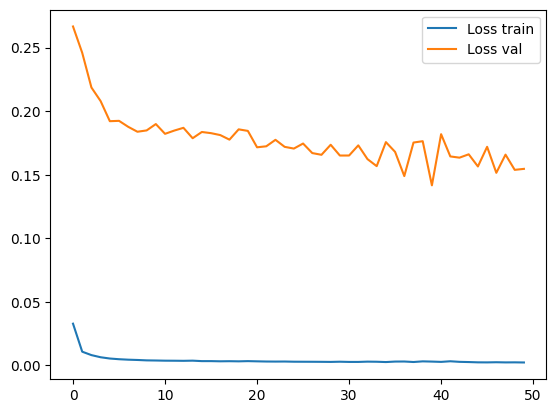

MAPE = 0.2865
MAE = 0.6584


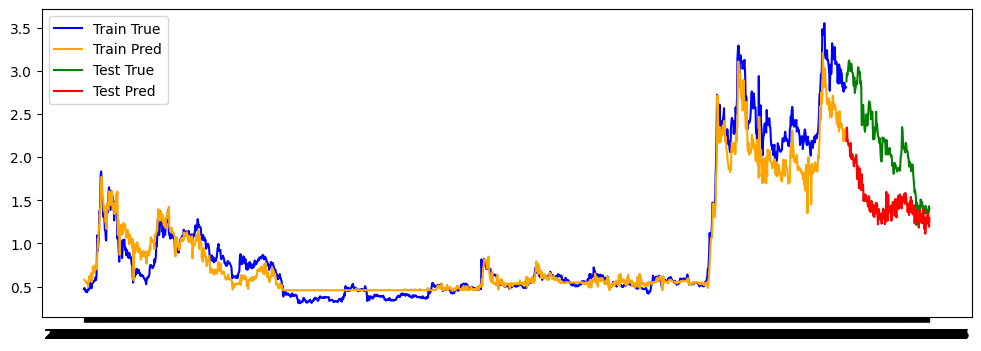

In [238]:
tcn_xrp_halfyear = tcn_model_creation(xrp_5years, steps = 180, lookback = 1, n_features = xrp_5years.shape[1], batch_size = len(xrp_5years) // 40, epochs = 200)

РИПЛ:
Месяц:

MAPE = 0.1168
MAE = 0.1630
lb = 1, bs = len//1, nb = 64, ker = 3, 0.3 dil = 1, 2, 8

MAPE = 0.0662
MAE = 0.0949
lb = 1, bs = len//1, nb = 64, ker = 4, dil = 1, 2, 4, 0.3 dense elu 32 0.7

Полгода:

MAPE = 0.3140
MAE = 0.7384
lb = 1, bs = len//1, nb = 16, ker = 4, dil = 1, 2, 8, 0.3

MAPE = 0.2239
MAE = 0.5086
lb = 1, bs = len//80, nb = 128, ker = 3, dil = 1, 2, 4, 64 0.6

MAPE = 0.2123
MAE = 0.4684
lb = 1, bs = len//100, nb = 128, ker = 3, dil = 1, 3, 27 0.4

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0726 - mae: 0.1616 - val_loss: 0.0086 - val_mae: 0.0793
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0307 - mae: 0.1098 - val_loss: 0.0040 - val_mae: 0.0499
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0212 - mae: 0.0911 - val_loss: 0.0035 - val_mae: 0.0473
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0169 - mae: 0.0800 - val_loss: 0.0032 - val_mae: 0.0456
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0139 - mae: 0.0725 - val_loss: 0.0033 - val_mae: 0.0469
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0123 - mae: 0.0682 - val_loss: 0.0029 - val_mae: 0.0438
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0114 - mae: 0.0654 - val_loss: 0.0029 - val_mae: 0.0434
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0105 - mae: 0.0626 - val_loss: 0.0028 - val_mae: 0.0425
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - lo

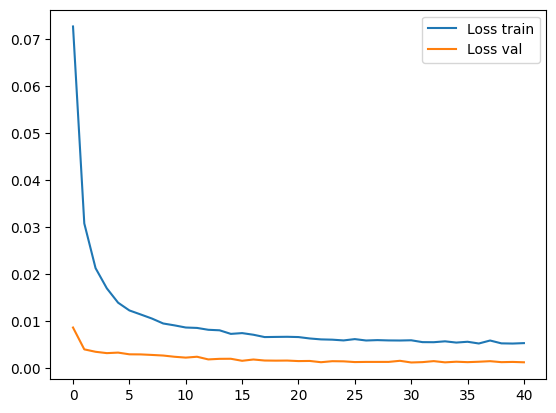

MAPE = 0.2078
MAE = 11.2515


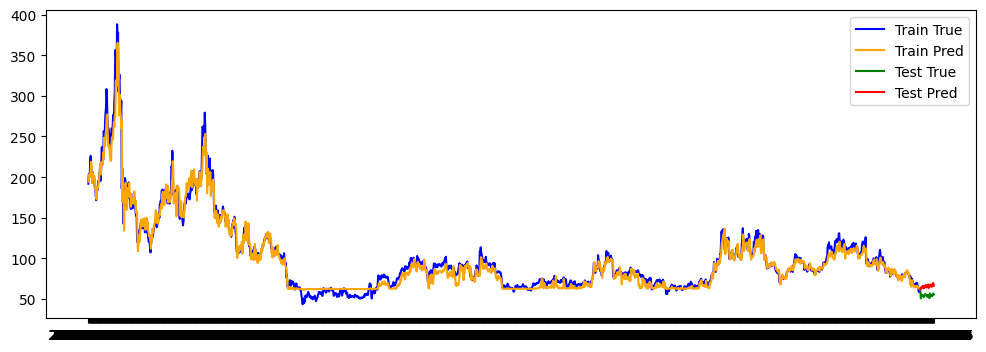

In [272]:
tcn_ltc_month = tcn_model_creation(ltc_5years, steps = 30, lookback = 1, n_features = ltc_5years.shape[1], batch_size = len(ltc_5years) // 25, epochs = 200)

Epoch 1/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0334 - mae: 0.1154 - val_loss: 0.0093 - val_mae: 0.0765
Epoch 2/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0182 - mae: 0.0883 - val_loss: 0.0080 - val_mae: 0.0707
Epoch 3/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0172 - mae: 0.0873 - val_loss: 0.0067 - val_mae: 0.0635
Epoch 4/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0140 - mae: 0.0790 - val_loss: 0.0062 - val_mae: 0.0605
Epoch 5/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0125 - mae: 0.0744 - val_loss: 0.0060 - val_mae: 0.0593
Epoch 6/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0116 - mae: 0.0716 - val_loss: 0.0057 - val_mae: 0.0579
Epoch 7/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0113 - mae: 0.0703 - val_loss: 0.0056 - val_mae: 0.0566
Epoch 8/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0107 - mae: 0.0684 - val_loss: 0.0054 - val_mae: 0.0561
Epoch 9/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.010

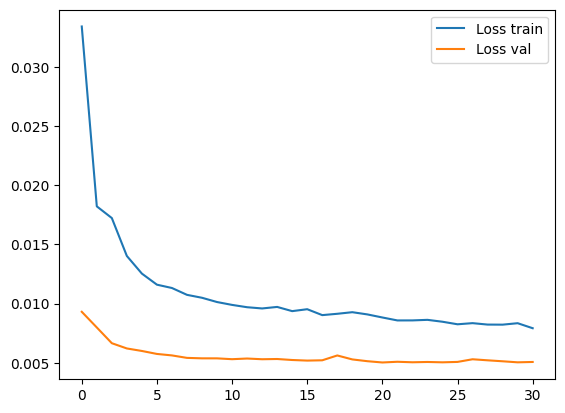

MAPE = 0.1732
MAE = 12.5112


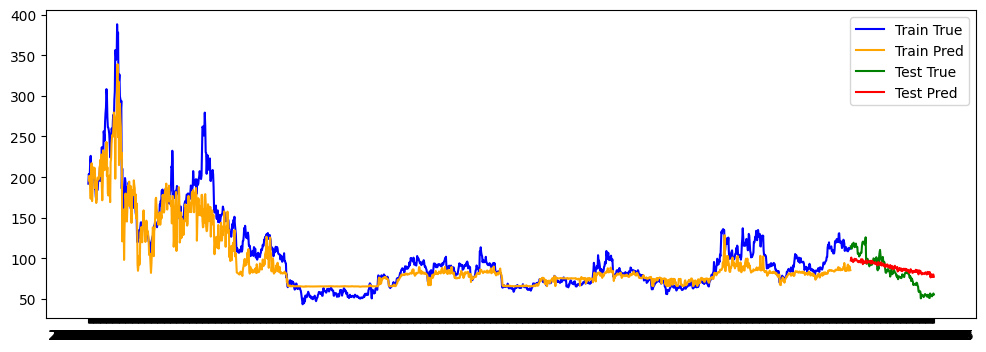

In [317]:
tcn_ltc_halfyear = tcn_model_creation(ltc_5years, steps = 180, lookback = 1, n_features = ltc_5years.shape[1], batch_size = len(ltc_5years) // 100, epochs = 200)

LITECOIN xD:

**Месяц**:

MAPE = 0.2080
MAE = 11.2516
lb = 1, bs = len//50, nb = 128, ker = 6, dil = 1, 3, 27, 0.3

MAPE = 0.1848
MAE = 9.9944
lb = 1, bs = len//20, nb = 64, ker = 4, dil = 1, 9, 27, 0.3

**Полгода**:

MAPE = 0.1683
MAE = 12.2617
lb = 1, bs = len//100, nb = 64, ker = 3, dil = 1, 9, 81, 0.3

MAPE = 0.1578
MAE = 11.5516
lb = 1, bs = len//100, nb = 128, ker = 4, dil = 1, 2, 4, 64 0.3



**Chronos**

In [11]:
import torch
from chronos import ChronosPipeline 

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-large",
    device_map="cpu",
    dtype=torch.float32
)

In [8]:
def train_test(df, horizon):
    train = df.iloc[:-horizon]
    test = df.iloc[-horizon:]
    return train['close'].values, test['close'].values

def chronos_forecast(train, horizon):

    context = torch.tensor(train, dtype=torch.float32)

    forecast = pipeline.predict(
        context,
        prediction_length = horizon,
        num_samples = 5
    )

    forecast = forecast.numpy()[0]
    # print(forecast.shape)
    return forecast.mean(axis = 0)

def run_chronos(series, horizon):

    train, test = train_test(series, horizon)

    pred = chronos_forecast(train, horizon)
    
    mae = mean_absolute_error(test, pred)
    mape = mean_absolute_percentage_error(test, pred)
    print(f"MAE = {mae:.2f}")
    print(f"MAPE = {mape:.2f}")

    plt.figure(figsize=(10,5))
    plt.plot(test, label="True values")
    plt.plot(pred, label=f"Predicted {horizon} days")
    plt.legend()
    plt.show()
    return pred


MAE = 5623.81
MAPE = 0.08


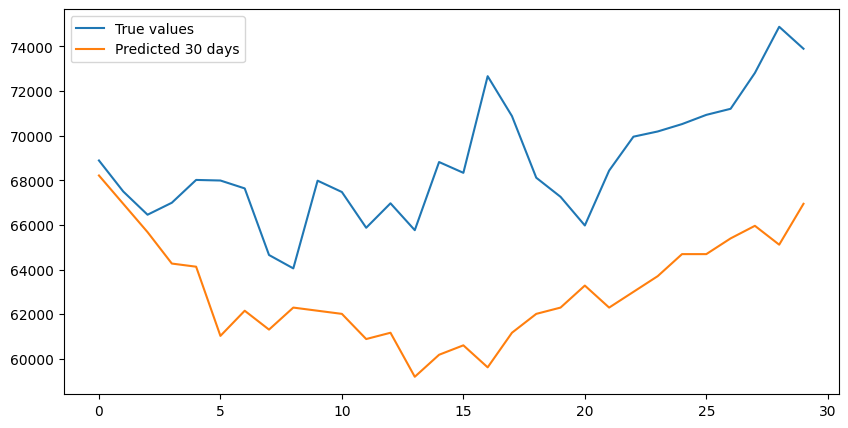

In [13]:
chronos_btc_month = run_chronos(btc_5years, 30)

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


MAE = 27204.99
MAPE = 0.34


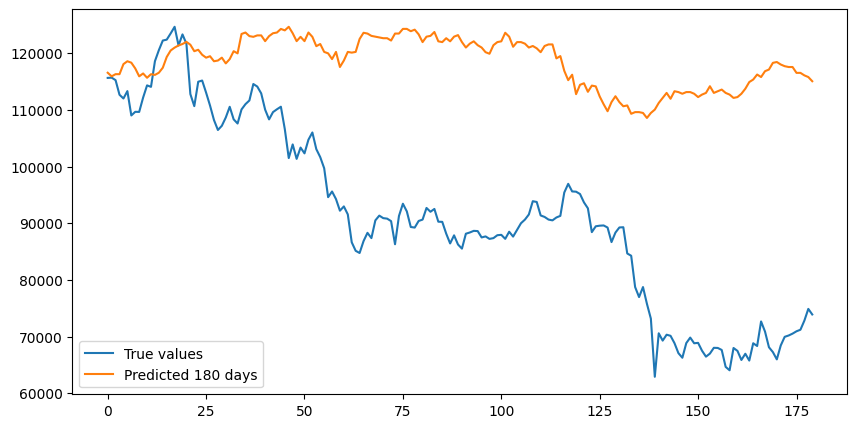

In [14]:
chronos_btc_month = run_chronos(btc_5years, 180)

chronos-t5-base

**BTC**

n samples = 4, далее среднее по прогнозам

месяц средний mape 0.11 mae ~8200

пол года средний mape 0.25 mae ~25000

MAE = 110.33
MAPE = 0.05


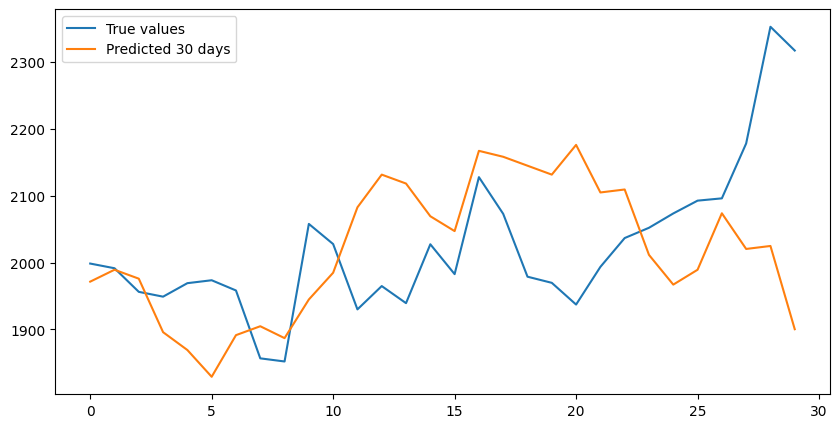

In [15]:
chronos_eth_month = run_chronos(eth_5years, 30)

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


MAE = 1413.51
MAPE = 0.54


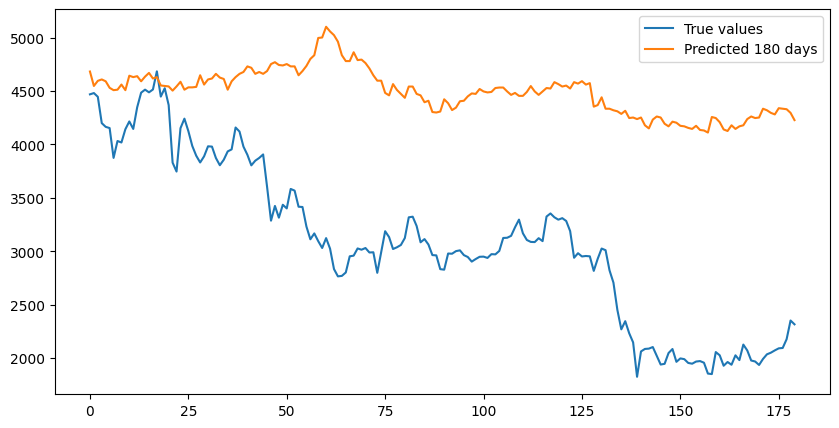

In [16]:
chronos_eth_halfyear = run_chronos(eth_5years, 180)

chronos-t5-base

**ETH**

n samples = 10, далее среднее по прогнозам

месяц средний mape 0.16 mae ~350

пол года средний mape 0.27 mae ~730

MAE = 0.25
MAPE = 0.18


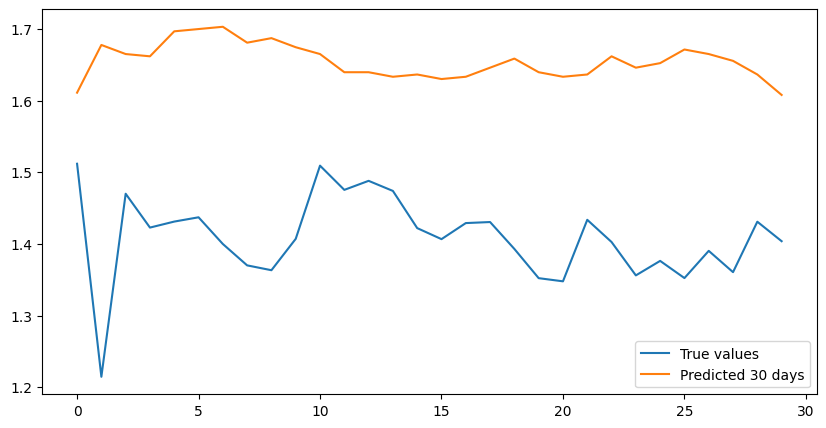

In [146]:
chronos_xrp_month = run_chronos(xrp_5years, 30)

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


MAE = 1.13
MAPE = 0.63


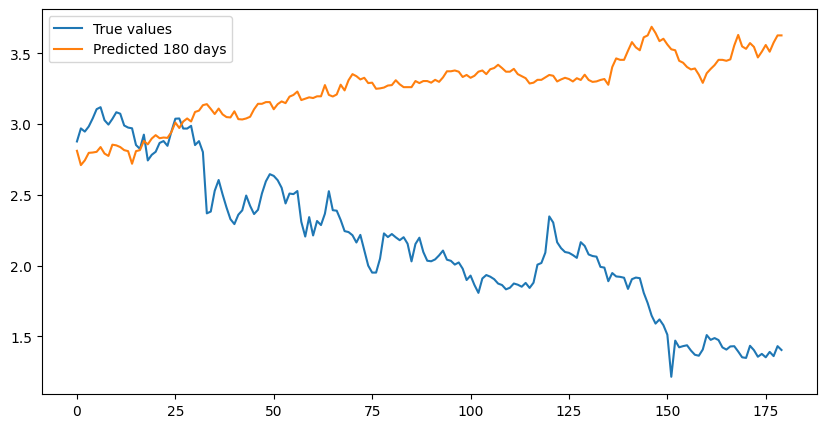

In [152]:
chronos_xrp_halfyear = run_chronos(xrp_5years, 180)

chronos-t5-base

**XRP**

n samples = 5, далее среднее по прогнозам

месяц средний mape 0.18 mae ~0.25

пол года средний mape 0.63 mae ~1.13

MAE = 6.84
MAPE = 0.13


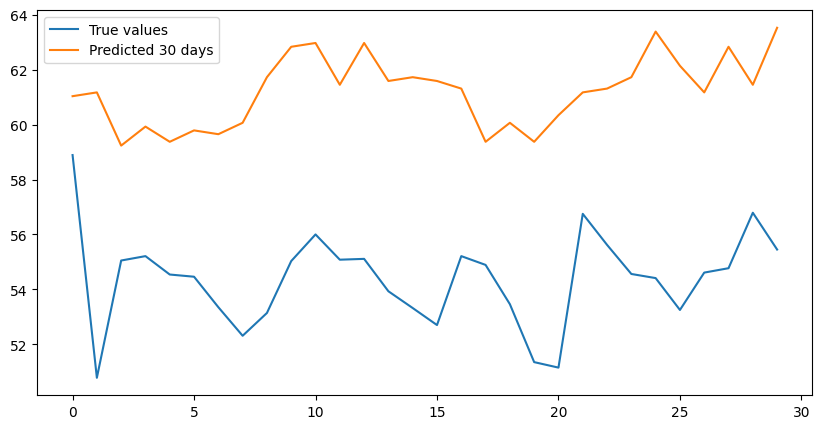

In [165]:
chronos_ltc_month = run_chronos(ltc_5years, 30)

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


MAE = 44.40
MAPE = 0.65


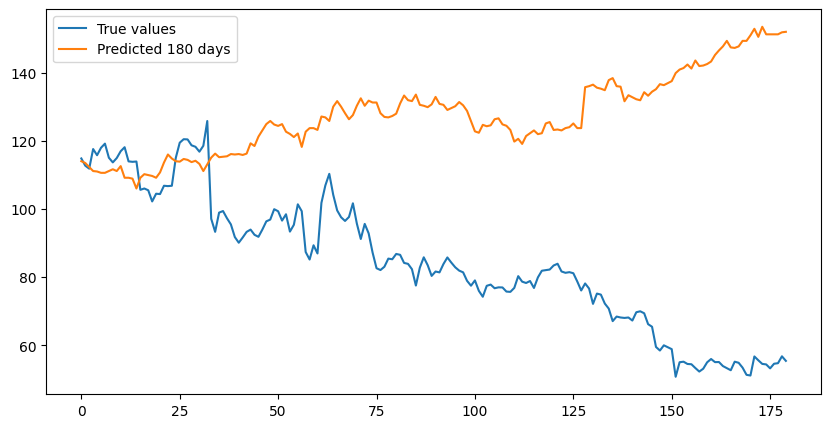

In [175]:
chronos_ltc_halfyear = run_chronos(ltc_5years, 180)

chronos-t5-base

**LTC**

n samples = 5, далее среднее по прогнозам

месяц средний mape 0.1 mae ~6.2

пол года средний mape 0.65 mae ~44.4

In [15]:
def hybrid_forecast(data, price_column='close', forecast_days=30, lags=10, lookback=10, 
                   plot_results=True, return_predictions=False):
    """
    Гибридная модель XGBoost + LSTM для прогнозирования временных рядов
    
    Параметры:
    -----------
    data : pandas.DataFrame или pandas.Series
        Входные данные. Если DataFrame, должен содержать колонку с ценами
    price_column : str
        Название колонки с ценами (если data - DataFrame)
    forecast_days : int
        Количество дней для прогноза (размер тестовой выборки)
    lags : int
        Количество лагов для XGBoost
    lookback : int
        Размер окна для LSTM
    plot_results : bool
        Отображать графики результатов
    return_predictions : bool
        Возвращать ли предсказания
    """
    
    # ===============================
    # Подготовка данных
    # ===============================
    
    if isinstance(data, pd.DataFrame):
        if price_column in data.columns:
            price = data[price_column]
        else:
            raise ValueError(f"Колонка '{price_column}' не найдена. Доступные колонки: {data.columns.tolist()}")
    elif isinstance(data, pd.Series):
        price = data
    else:
        raise ValueError("data должен быть pandas DataFrame или Series")
    
    # Проверка индекса
    if not isinstance(price.index, pd.DatetimeIndex):
        try:
            price.index = pd.to_datetime(price.index)
            use_numeric_index = False
        except:
            print("⚠️ Индекс не является датой. Будет использован числовой индекс для графиков.")
            use_numeric_index = True
    else:
        use_numeric_index = False
    
    # ===============================
    # Создание лагов для XGBoost
    # ===============================
    
    X = []
    y = []
    
    for i in range(lags, len(price)):
        X.append(price.values[i-lags:i])
        y.append(price.values[i])
    
    X = np.array(X)
    y = np.array(y)
    
    # ===============================
    # Разделение на train/test
    # Размер теста = forecast_days
    # ===============================
    
    test_size = forecast_days
    train_size = len(X) - test_size
    
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    

    xgb_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        objective="reg:squarederror",
        random_state=42
    )
    
    xgb_model.fit(X_train, y_train)
    
    xgb_train_pred = xgb_model.predict(X_train)
    xgb_test_pred = xgb_model.predict(X_test)

    
    train_residuals = y_train - xgb_train_pred
    
    # Масштабирование остатков
    scaler = MinMaxScaler()
    res_scaled = scaler.fit_transform(train_residuals.reshape(-1, 1))
    
    # ===============================
    # Создание последовательностей для LSTM
    # ===============================
    
    X_lstm = []
    y_lstm = []
    
    for i in range(lookback, len(res_scaled)):
        X_lstm.append(res_scaled[i-lookback:i])
        y_lstm.append(res_scaled[i])
    
    X_lstm = np.array(X_lstm)
    y_lstm = np.array(y_lstm)
    
    lstm_model = Sequential()
    lstm_model.add(LSTM(50, input_shape=(lookback, 1)))
    lstm_model.add(Dense(1))
    lstm_model.compile(optimizer="adam", loss="mse")
    early_stop = EarlyStopping(patience=5, restore_best_weights=True)

    lstm_model.fit(
        X_lstm, y_lstm,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
        )
    # ===============================
    # Прогнозирование на ТЕСТОВЫХ данных
    # ===============================
    
    last_residuals = train_residuals[-lookback:].reshape(-1, 1)
    last_residuals_scaled = scaler.transform(last_residuals)
    
    test_residual_preds = []
    current_seq = last_residuals_scaled.flatten()
    
    # Прогнозируем остатки для всех тестовых точек
    for i in range(len(X_test)):
        pred = lstm_model.predict(current_seq.reshape(1, lookback, 1), verbose=0)
        test_residual_preds.append(pred[0, 0])
        
        # Обновляем последовательность для следующего шага
        # Используем предсказанное значение (так как реальных остатков на тесте у нас нет)
        current_seq = np.append(current_seq[1:], pred)
    
    # Обратное масштабирование предсказанных остатков
    test_residual_preds = scaler.inverse_transform(
        np.array(test_residual_preds).reshape(-1, 1)
    ).flatten()
    
    # ===============================
    # Финальные гибридные предсказания на тестовых данных
    # ===============================
    
    hybrid_test_pred = xgb_test_pred + test_residual_preds
    
    # ===============================
    # Метрики качества на ТЕСТОВЫХ данных
    # ===============================
    
    mae = mean_absolute_error(y_test, hybrid_test_pred)
    mape = np.mean(np.abs((y_test - hybrid_test_pred) / y_test)) * 100
    
    print(f"   MAE: {mae:.2f}")
    print(f"   MAPE: {mape:.2f}%")
    # ===============================
    # Визуализация полного исторического периода с прогнозом
    # ===============================
    
    if plot_results:
        if not use_numeric_index and isinstance(price.index, pd.DatetimeIndex):
            plt.figure(figsize=(10, 5))
            
            # Исторические данные (тренировка + тест)
            plt.plot(price.index, price, label="Исторические данные", linewidth=1.5, color='blue', alpha=0.7)
            
            # Выделяем тренировочные данные
            train_end_idx = train_size + lags  # +lags из-за создания лагов
            if train_end_idx < len(price):
                plt.axvspan(price.index[0], price.index[train_end_idx-1], 
                           alpha=0.1, color='green', label='Тренировочные данные')
            
            # Прогноз на тестовых данных
            test_start_idx = train_size + lags
            if test_start_idx < len(price):
                test_indices = price.index[test_start_idx:test_start_idx + len(hybrid_test_pred)]
                plt.plot(test_indices, hybrid_test_pred, 
                        label=f"Гибридный прогноз (тест)", linewidth=2, color='red')
            
            plt.axvline(x=price.index[train_size + lags] if train_size + lags < len(price) else price.index[-1], 
                       color='gray', linestyle='--', alpha=0.7, label='Граница train/test')
            
            plt.title(f"Гибридная модель XGBoost + LSTM\n"
                     f"Прогноз на {forecast_days} дней, MAPE на тесте: {mape:.2f}%")
            plt.xlabel("Дата")
            plt.ylabel("Цена")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            
    if return_predictions:
        if not use_numeric_index and isinstance(price.index, pd.DatetimeIndex):
            test_start_idx = train_size + lags
            test_indices = price.index[test_start_idx:test_start_idx + len(hybrid_test_pred)]
            train_indices = price.index[lags:train_size + lags]
        else:
            test_indices = range(len(y_test))
            train_indices = range(len(y_train))
        
        return {
            'historical': price,
            'train_data': {
                'X': X_train,
                'y': y_train,
                'indices': train_indices
            },
            'test_data': {
                'X': X_test,
                'y': y_test,
                'indices': test_indices
            },
            'predictions': {
                'hybrid_test': pd.Series(hybrid_test_pred, index=test_indices),
                'xgb_test': pd.Series(xgb_test_pred, index=test_indices),
                'xgb_train': pd.Series(xgb_train_pred, index=train_indices)
            },
            'metrics': {
                'test': {
                    'hybrid_mae': mae,
                    'hybrid_mape': mape
                }
            },
            'model': {
                'xgb': xgb_model,
                'lstm': lstm_model,
                'scaler': scaler
            },
            'params': {
                'forecast_days': forecast_days,
                'lags': lags,
                'lookback': lookback,
                'train_size': train_size,
                'test_size': test_size
            }
        }

**BTC**

d:\модели_вкр\.myvenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   MAE: 1625.95
   MAPE: 2.34%


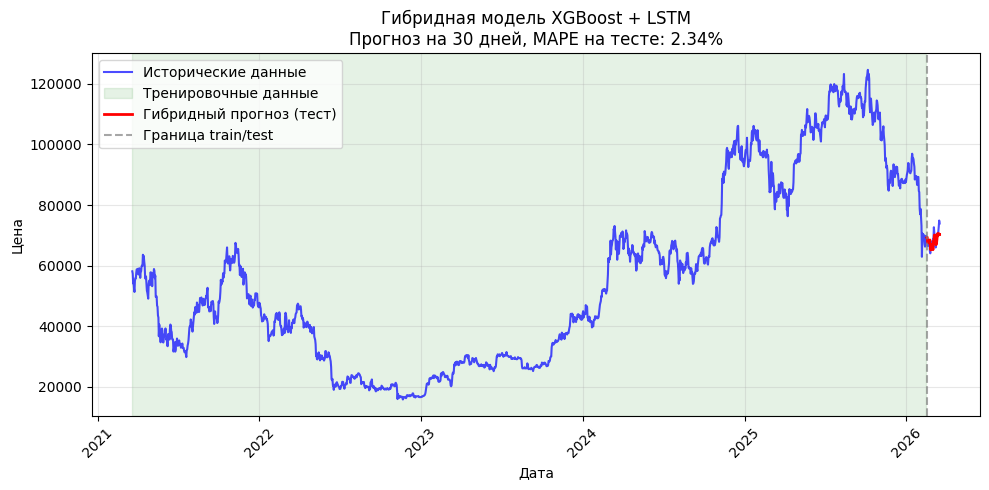

In [17]:
# Запуск прогноза
hybrid_forecast(
    data=btc_5years,
    price_column = 'close',  # название колонки с ценами
    forecast_days = int(30)      # количество дней для прогноза
)

d:\модели_вкр\.myvenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   MAE: 2041.06
   MAPE: 2.33%


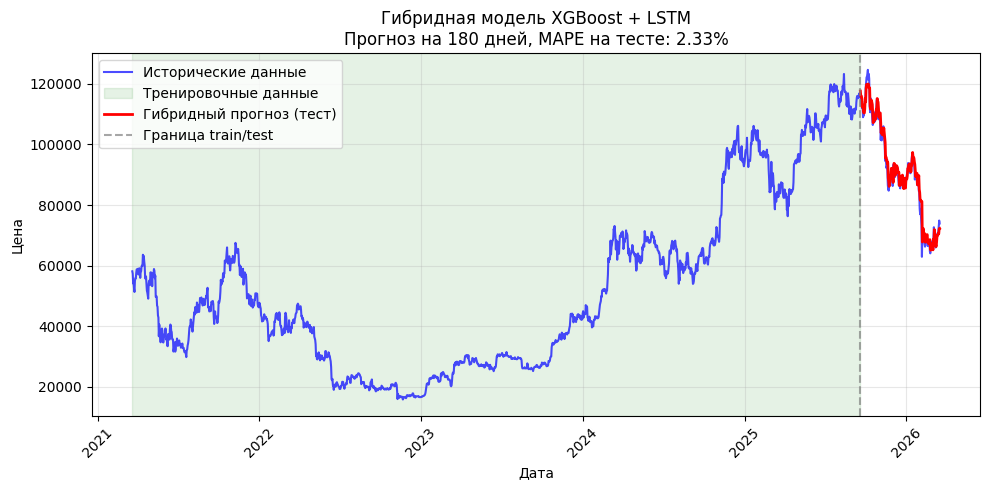

In [16]:
# Запуск прогноза
hybrid_forecast(
    data=btc_5years,
    price_column = 'close',  # название колонки с ценами
    forecast_days = 180      # количество дней для прогноза
)

**ETH**

   MAE: 76.26
   MAPE: 3.83%


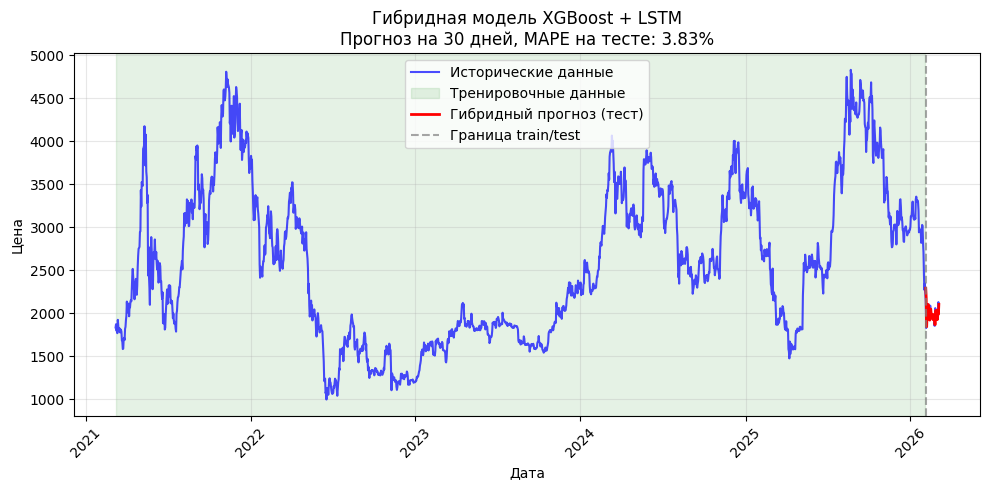

In [49]:
# Запуск прогноза
hybrid_forecast(
    data=eth_5years,
    price_column = 'close',  # название колонки с ценами
    forecast_days = 30      # количество дней для прогноза
)

   MAE: 100.44
   MAPE: 3.15%


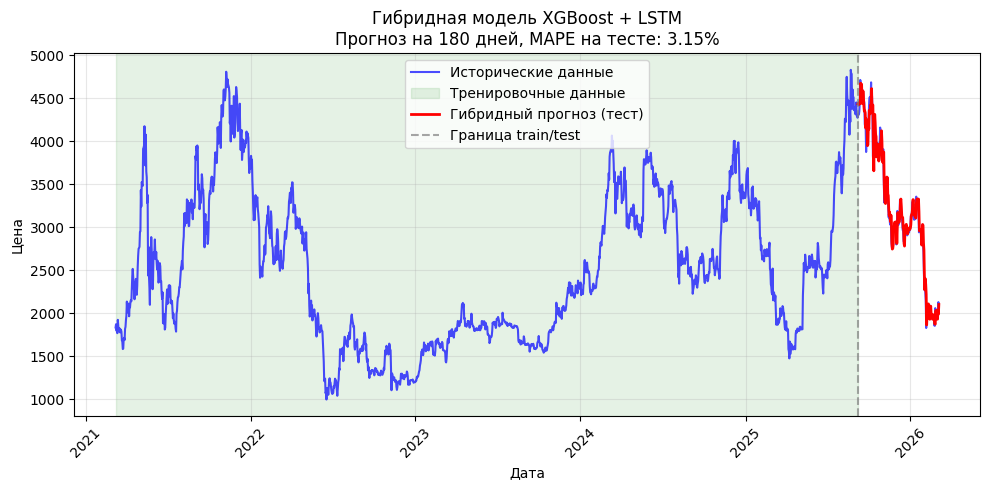

In [50]:
# Запуск прогноза
hybrid_forecast(
    data=eth_5years,
    price_column = 'close',  # название колонки с ценами
    forecast_days = 180      # количество дней для прогноза
)

**XRP**

   MAE: 0.06
   MAPE: 4.12%


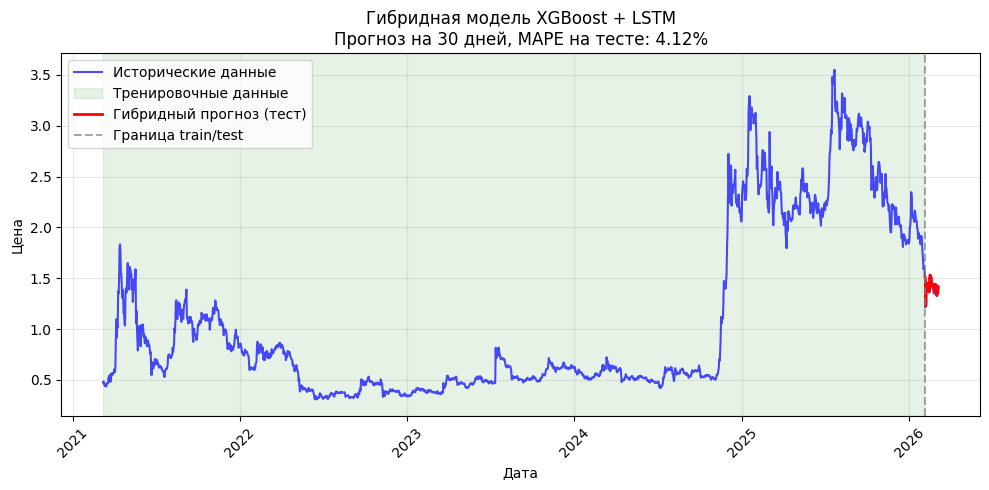

In [51]:
# Запуск прогноза
hybrid_forecast(
    data=xrp_5years,
    price_column = 'close',  # название колонки с ценами
    forecast_days = 30      # количество дней для прогноза
)

   MAE: 0.07
   MAPE: 3.07%


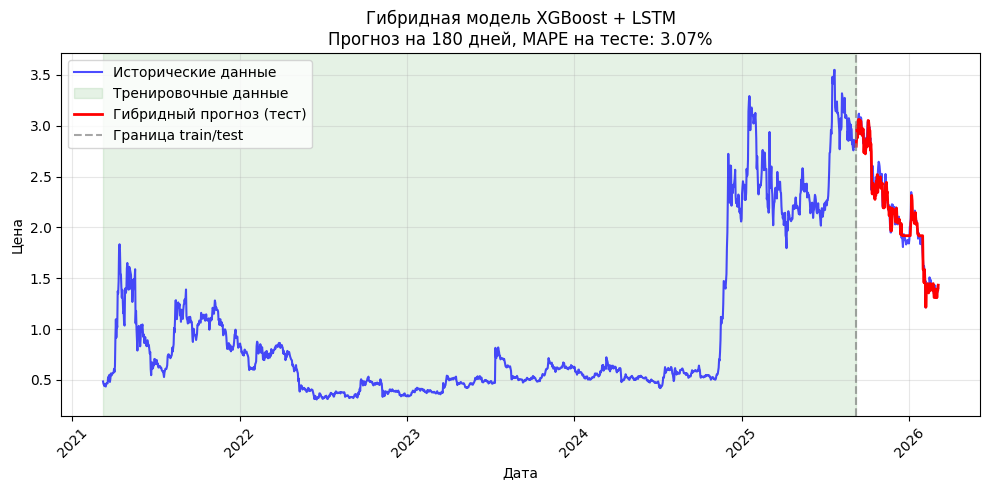

In [39]:
# Запуск прогноза
hybrid_forecast(
    data=xrp_5years,
    price_column = 'close',  # название колонки с ценами
    forecast_days = 180      # количество дней для прогноза
)

**LTC**

   MAE: 1.66
   MAPE: 3.09%


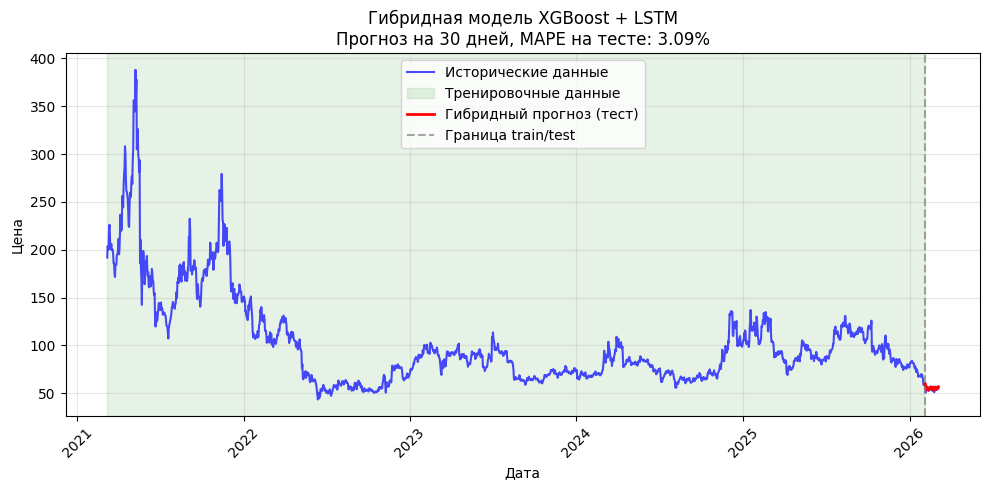

In [53]:
# Запуск прогноза
hybrid_forecast(
    data=ltc_5years,
    price_column = 'close',  # название колонки с ценами
    forecast_days = 30      # количество дней для прогноза
)

   MAE: 2.66
   MAPE: 3.24%


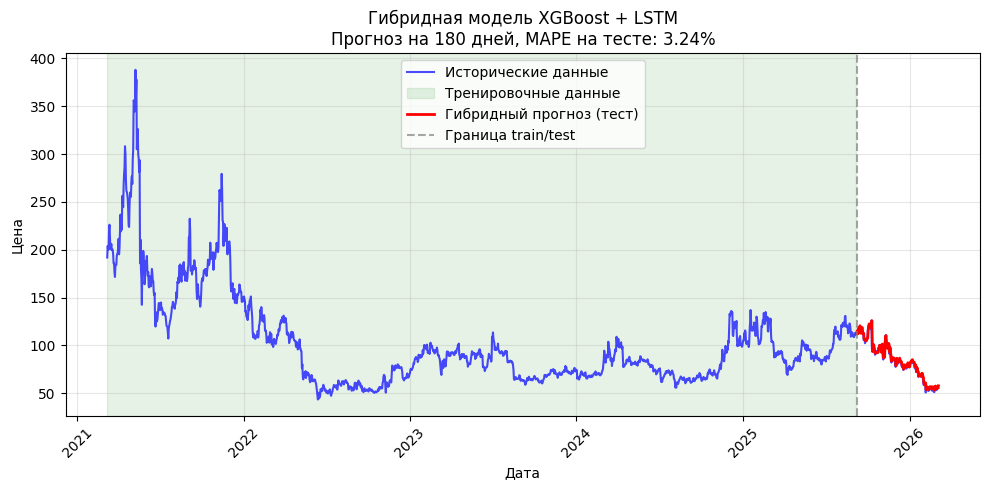

In [54]:
# Запуск прогноза
hybrid_forecast(
    data=ltc_5years,
    price_column = 'close',  # название колонки с ценами
    forecast_days = 180      # количество дней для прогноза
)